#  Machine Learning Project  
## **Classification & Regression Analysis**  
### Telco Customer Churn & Medical Insurance Dataset  


**Author:** Zemenawit Kahsay  

**Instructor:** Amit Kukreja

**Submissin Date:** December 10, 2025  

**Course:** MLDLAI — Metro College of Technology

## **Executive Summary**

This project focuses on two predictive modeling tasks using separate datasets: customer churn classification based on the Telco Customer Churn dataset, and medical insurance cost prediction using the Medical Insurance dataset. For both datasets, the full machine-learning pipeline was implemented, beginning with data importation, cleaning, handling missing values, and conducting both univariate and bivariate exploratory analysis to understand feature distributions and relationships. Outliers were identified using the Local Outlier Factor (LOF) method, and appropriate transformations—including encoding categorical variables, scaling numerical features, and performing PCA where needed—were applied to prepare the data for modeling. Multiple algorithms were then developed for each problem, followed by hyperparameter tuning using GridSearchCV to optimize model performance. Model evaluation included accuracy metrics,confusion matrices and  ROC-AUC (for classification), R² and RMSE (for regression), and 5-fold cross-validation to assess generalization. Each model was examined for signs of overfitting, and final conclusions were drawn by comparing all models and selecting the best-performing ones for each prediction task. This comprehensive workflow ensures a robust and well-validated analysis for both classification and regression problems.

# Import Libraries

In [ ]:

# ============================
# Import libraries
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,roc_auc_score,
    r2_score, mean_squared_error
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import  DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, AdaBoostRegressor,AdaBoostClassifier
from sklearn.svm import SVC, SVR
from xgboost import XGBRegressor,XGBClassifier

from scipy.stats import chi2_contingency, pearsonr

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

import warnings
warnings.filterwarnings("ignore")

# PART 1 – Classification: Telco Customer Churn

## Import Data

In [ ]:
#Load data
df=pd.read_csv("telco-customer-churn.csv")

## EDA(Exploratory Data Analysis)

In [ ]:
# shape of data
print("Shape of Telco dataset:", df.shape)

In [228]:
# Brows Data Portion
# Head of data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [229]:
# tail of data
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [230]:
#head and tail
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [231]:
# Brows discriptor portion
##checking  number of obs and columns ,index of columns, name of columns, number of non_null values and datatype, (memory usage,...)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [232]:
# find number of missing values
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [233]:
# Check duplicate records
dup_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", dup_count)


Number of duplicate rows: 0


In [234]:
# get the summary of Data
# for only numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [235]:
# for all columns
df.astype('object').describe().T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
SeniorCitizen,7043,2,0,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
tenure,7043,73,1,613
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498


# Data Prepration

## Data Cleansing
1. Handling Duplicate Data
2. Handling Missing Values
3. Handling Outliers

In [236]:
# since column Customer id is insignificant, drop the column
df=df.drop("customerID",axis=1)

In [237]:
# 'TotalCharges' is numeric but stored as object (string); convert to numeric.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
#SeniorCitizen is categorical but stored as int: convert to categorical
df['SeniorCitizen'] = df['SeniorCitizen'].astype(str)

In [238]:
# check data types
df.dtypes

gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

### 1. Handling Duplicate Data

In [239]:
# Find number of duplicated rows
df.duplicated().sum()

np.int64(22)

In [240]:
# Get a copy of data
df_original=df.copy()

In [241]:
df_2=df.drop_duplicates()
df.shape, df_2.shape, df.shape[0]-df_2.shape[0]

((7043, 20), (7021, 20), 22)

In [242]:
df=df_2.copy()# copy by value

### 2. Handling Missing Values

In [243]:
# find number of missing values
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


The Telco Customer Churn dataset contains only one column with missing values, TotalCharges(11rows). Since 11 rows represent 0.15% of the dataset,dropping them will not impact model performance. I remove those 11 rows as part of data cleaning.


In [244]:
df=df.dropna()

In [245]:
#check missing values 
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [246]:
print("\nShape after dropping rows with missing TotalCharges:", df.shape)


Shape after dropping rows with missing TotalCharges: (7010, 20)


## UNIVARIATE ANALYSIS

In [247]:
# get all categorical columns:
df_cat=df.select_dtypes(include='object')
df_cat.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [248]:
# get all numerical columns:
df_num=df.select_dtypes(include=['int64','float64'])
df_num.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [249]:
# Find the frequency of each levels in all categorcal columns
for c in df_cat.columns:
    print(df[c].value_counts())
    print("="*30)

gender
Male      3535
Female    3475
Name: count, dtype: int64
SeniorCitizen
0    5869
1    1141
Name: count, dtype: int64
Partner
No     3617
Yes    3393
Name: count, dtype: int64
Dependents
No     4911
Yes    2099
Name: count, dtype: int64
PhoneService
Yes    6330
No      680
Name: count, dtype: int64
MultipleLines
No                  3363
Yes                 2967
No phone service     680
Name: count, dtype: int64
InternetService
Fiber optic    3090
DSL            2414
No             1506
Name: count, dtype: int64
OnlineSecurity
No                     3489
Yes                    2015
No internet service    1506
Name: count, dtype: int64
OnlineBackup
No                     3079
Yes                    2425
No internet service    1506
Name: count, dtype: int64
DeviceProtection
No                     3086
Yes                    2418
No internet service    1506
Name: count, dtype: int64
TechSupport
No                     3464
Yes                    2040
No internet service    1506
Name: c

### Visualization

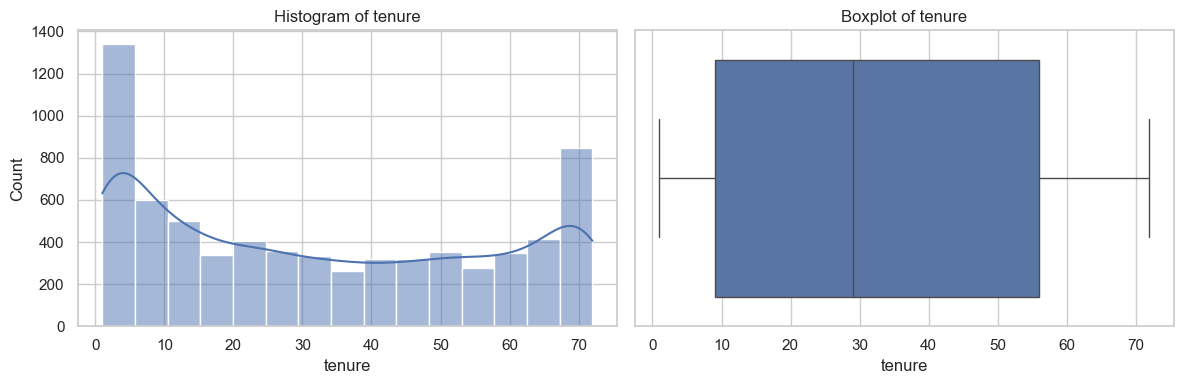

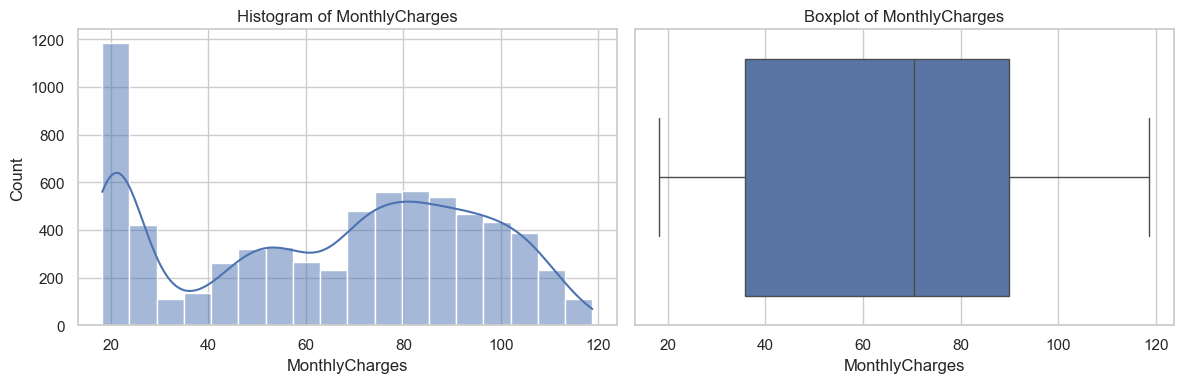

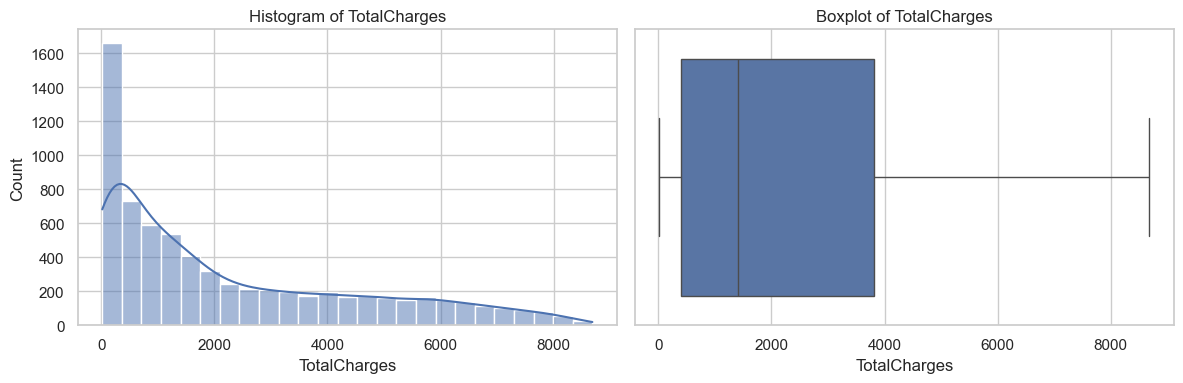

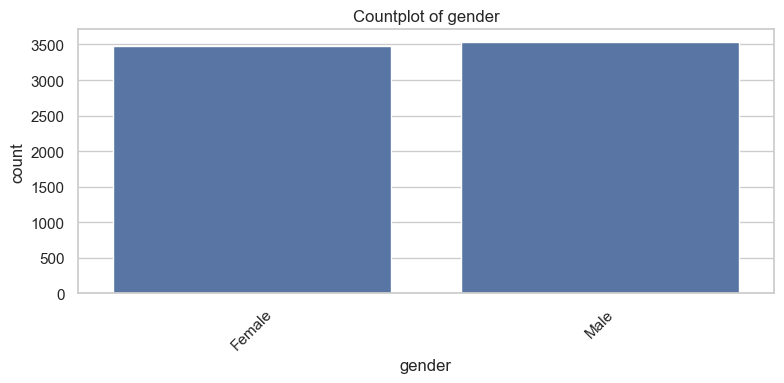

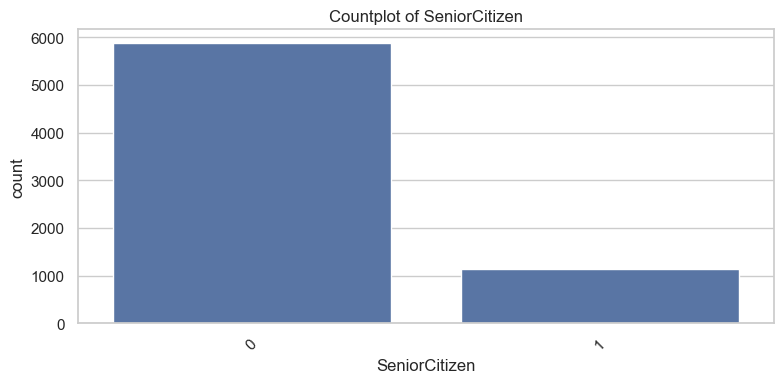

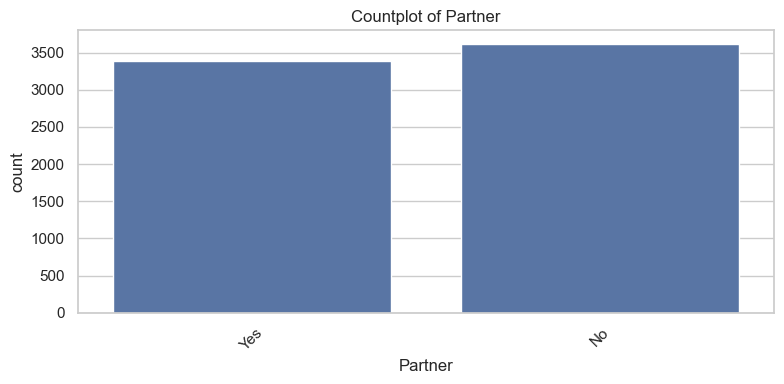

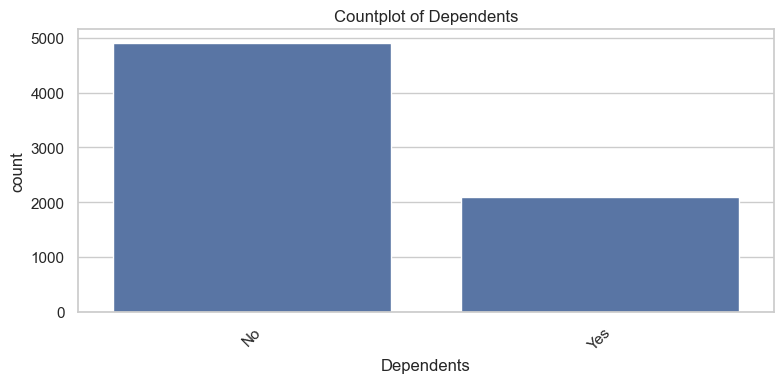

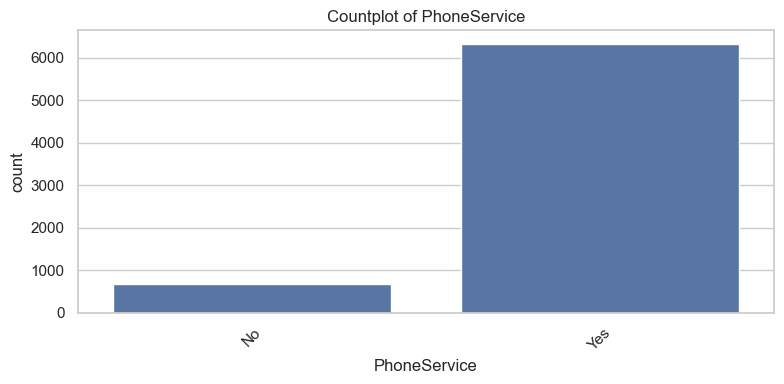

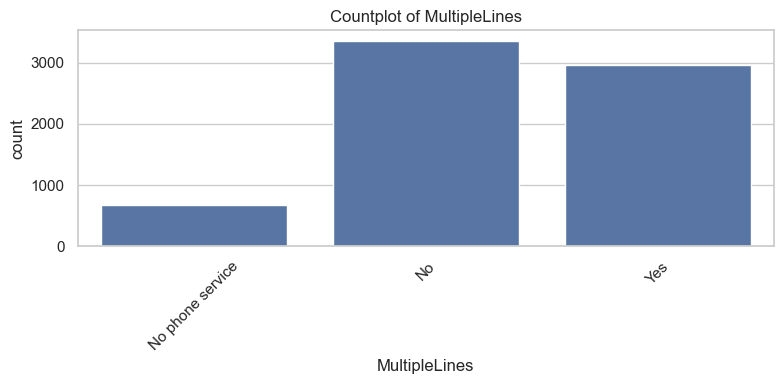

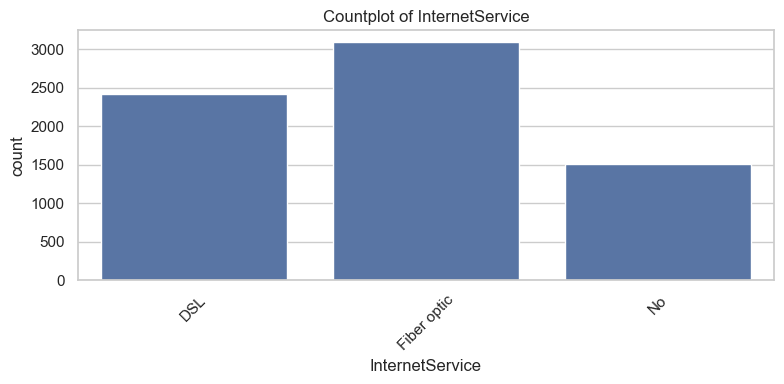

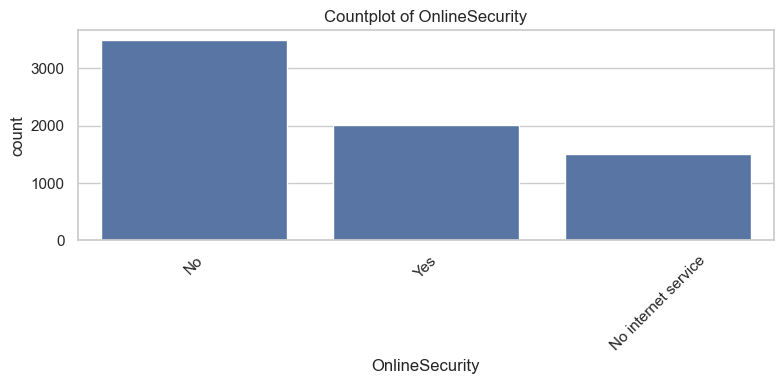

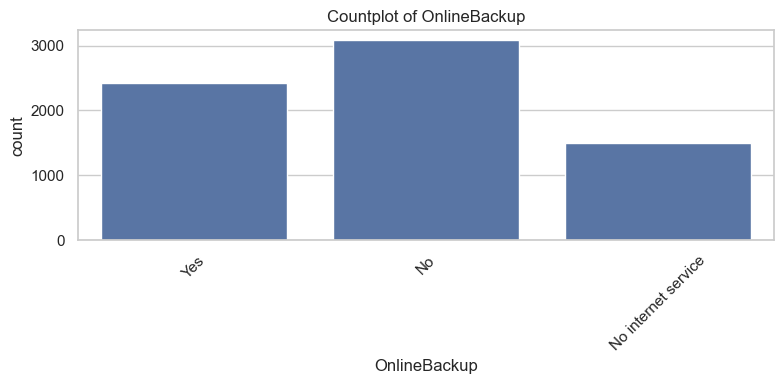

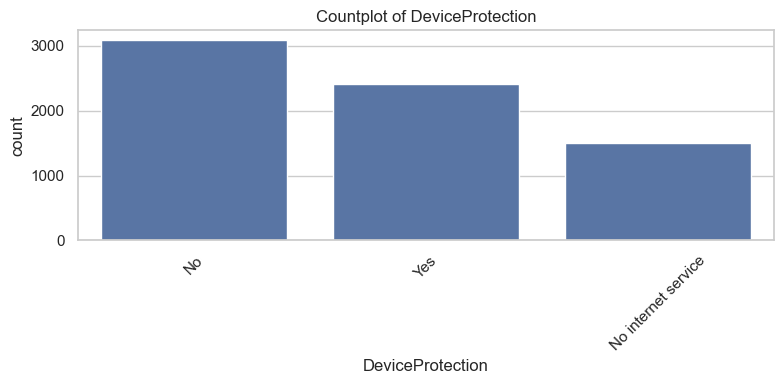

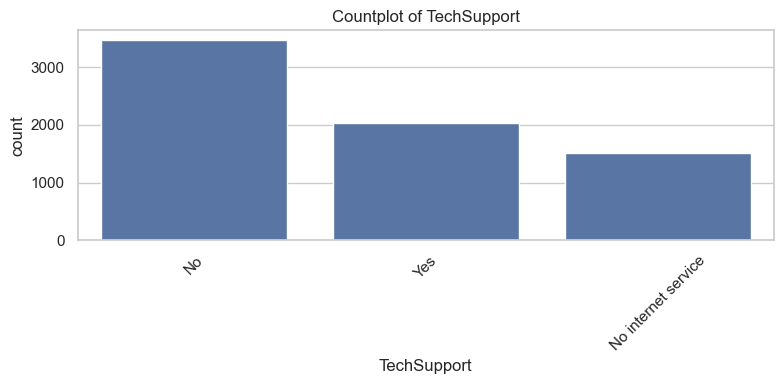

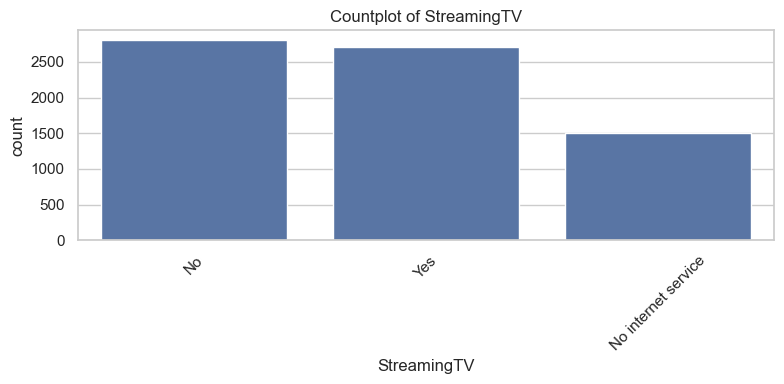

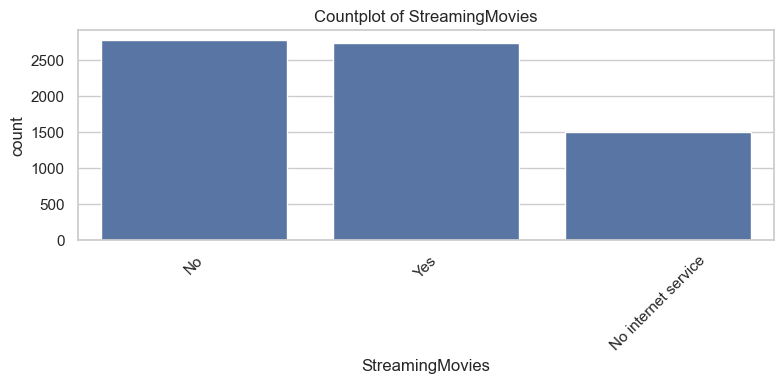

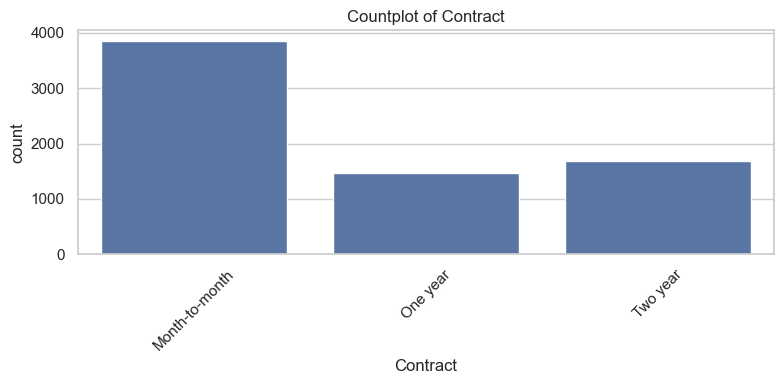

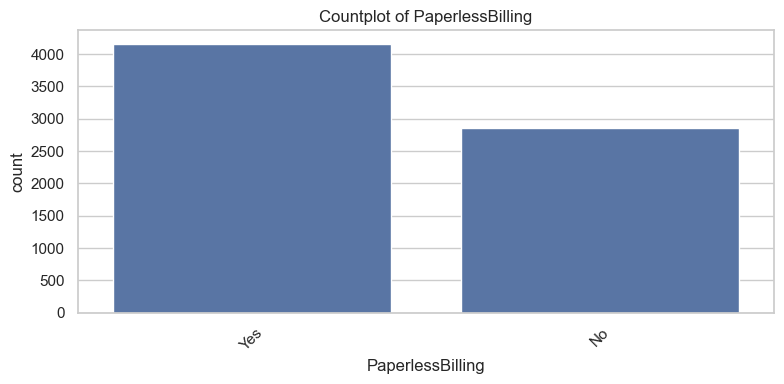

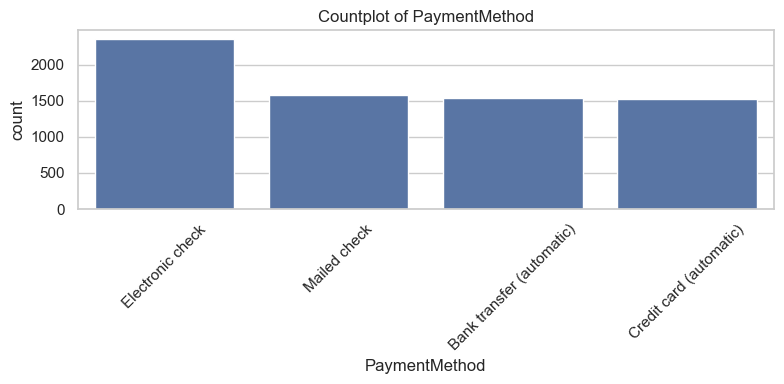

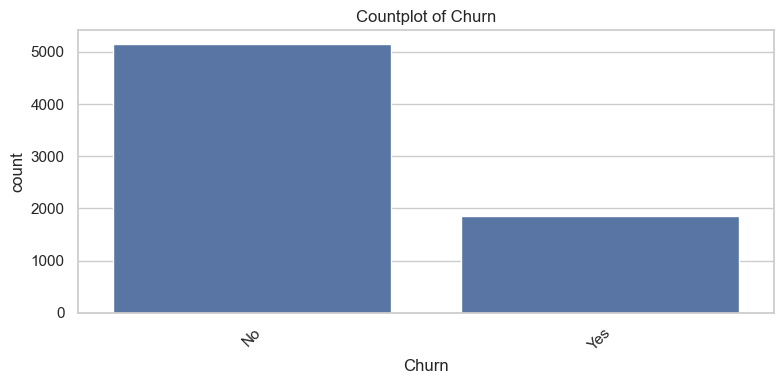

In [250]:
# --- Numeric variables: histograms & boxplots ---
for col in df_num.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {col}")
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    
    plt.tight_layout()
    plt.show()

# --- Categorical variables: countplots ---
for col in  df_cat.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [251]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7010.000000,7010.000000,7010.000000
mean,32.520399,64.888666,2290.353388
std,24.520441,30.064769,2266.820832
min,1.000000,18.250000,18.800000
25%,9.000000,35.750000,408.312500
50%,29.000000,70.400000,1403.875000
75%,56.000000,89.900000,3807.837500
max,72.000000,118.750000,8684.800000


In [252]:
df.astype("object").describe().T

,count,unique,top,freq
gender,7010,2,Male,3535
SeniorCitizen,7010,2,0,5869
Partner,7010,2,No,3617
Dependents,7010,2,No,4911
tenure,7010,72,1,591
PhoneService,7010,2,Yes,6330
MultipleLines,7010,3,No,3363
InternetService,7010,3,Fiber optic,3090
OnlineSecurity,7010,3,No,3489
OnlineBackup,7010,3,No,3079


#### Target - Churn

In [253]:
df['Churn'].value_counts()

Churn
No     5153
Yes    1857
Name: count, dtype: int64

In [254]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.735093
Yes    0.264907
Name: proportion, dtype: float64

### 3- Handling Outliers

In [255]:
# ============================================
# 4. OUTLIER DETECTION USING LOCAL OUTLIER FACTOR
# ============================================

# Select numeric columns correctly
numeric_cols = df.select_dtypes(include='number').columns

print("Numeric columns used for LOF:")
print(numeric_cols)

df_numeric = df[numeric_cols]

# Create LOF model
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)

# Fit and predict (-1 = outlier, 1 = normal)
outlier_labels = lof.fit_predict(df_numeric)

# Add results back into your dataframe
df['is_outlier_lof'] = (outlier_labels == -1)

print("Number of outliers detected:", df['is_outlier_lof'].sum())

df_clean = df[df['is_outlier_lof'] == False].copy()
print("Shape after removing outliers:", df_clean.shape)

Numeric columns used for LOF:
Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Number of outliers detected: 211
Shape after removing outliers: (6799, 21)


In [256]:
df_clean

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,is_outlier_lof
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,False
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,False
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,False
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,False
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,False
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,False
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,False
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,False


In [257]:
df_clean=df_clean.drop('is_outlier_lof',axis=1)

# BIVARIATE ANALYSIS

## 1- Chi-Square Test

H0 (Null Hypothesis):

There is no association between two Variables(They are statistically independent.)

H1 (Alternative Hypothesis):

There is an association between the Variables((They are not independent.)

#### InternetService vs Churn

In [258]:
contingency = pd.crosstab(df_clean['InternetService'], df_clean['Churn'])
contingency

Churn,No,Yes
InternetService,,
DSL,1897,404
Fiber optic,1783,1236
No,1378,101


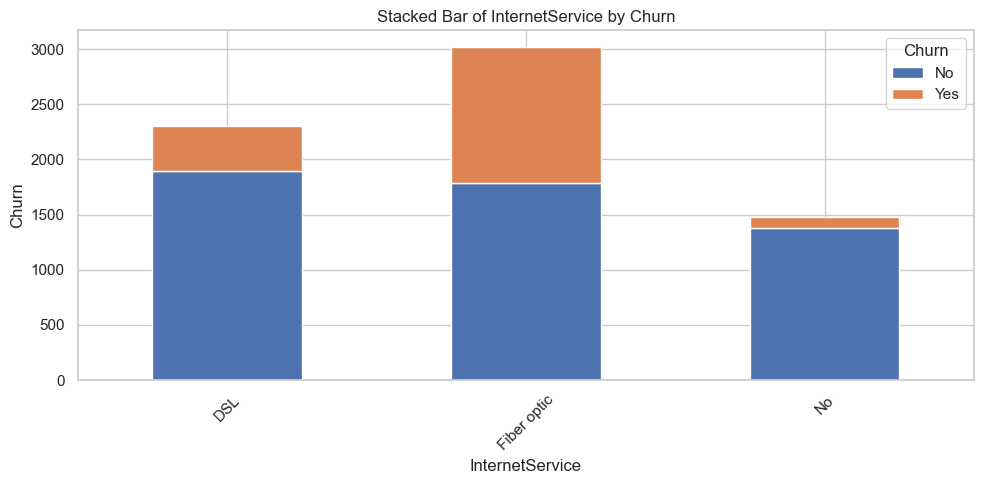

In [259]:
# Visualization
contingency.plot(kind='bar', stacked=True)
# Visualization
contingency.plot(kind='bar', stacked=True)

plt.title(f"Stacked Bar of InternetService by Churn")
plt.xlabel('InternetService')
plt.ylabel("Churn")
plt.xticks(rotation=45)
plt.legend(title='Churn', loc='upper right')
plt.tight_layout()
plt.show()

In [260]:
chi2, p, dof, expected = chi2_contingency(contingency)

print("\nChi-square test: InternetService vs Churn")
print("Chi-square statistic:", chi2)
print("p-value:", p)
if p < 0.05:
    print('There is association')
else:
    print("***There is no association***")
print("Degrees of freedom:", dof)
print("\nExpected counts:")
print(expected)


Chi-square test: InternetService vs Churn
Chi-square statistic: 724.6542456486661
p-value: 4.398756418099735e-158
There is association
Degrees of freedom: 2

Expected counts:
[[1711.78967495  589.21032505]
 [2245.93351964  773.06648036]
 [1100.27680541  378.72319459]]


The Chi-square test indicates a statistically significant association between Internet service type and Churn (p < 0.05). This means churn rates differ across Internet service types, and internet service type is strongly related to whether a customer churns.

#### PaymentMethod vs Churn

In [261]:
cont = pd.crosstab(df_clean['PaymentMethod'], df_clean['Churn'])
cont

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1266,249
Credit card (automatic),1274,225
Electronic check,1268,992
Mailed check,1250,275


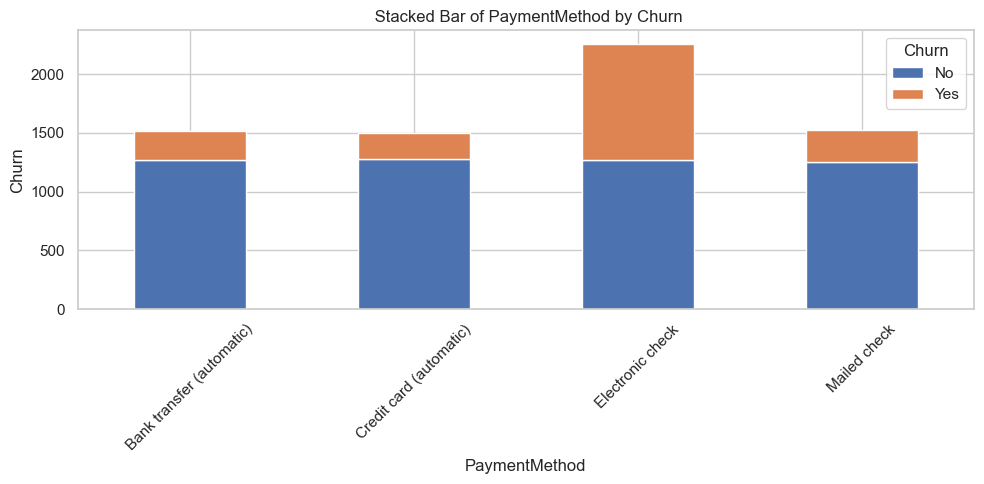

In [262]:
# Visualization
cont.plot(kind='bar', stacked=True)

plt.title(f" Stacked Bar of PaymentMethod by Churn")
plt.xlabel('PaymentMethod')
plt.ylabel("Churn")
plt.xticks(rotation=45)
plt.legend(title='Churn', loc='upper right')
plt.tight_layout()
plt.show()

In [263]:
chi2, p, dof, expected = chi2_contingency(cont)

print("\nChi-square test: PaymentMethod vs Churn")
print("Chi-square statistic:", chi2)
print("p-value:", p)
if p < 0.05:
    print('There is association')
else:
    print("***There is no association***")
print("Degrees of freedom:", dof)
print("\nExpected counts:")
print(expected)


Chi-square test: PaymentMethod vs Churn
Chi-square statistic: 597.9169116763882
p-value: 2.850869408147156e-129
There is association
Degrees of freedom: 3

Expected counts:
[[1127.05839094  387.94160906]
 [1115.15546404  383.84453596]
 [1681.28842477  578.71157523]
 [1134.49772025  390.50227975]]


Since the p-value is far below 0.05, we reject the null hypothesis.Payment Method type and churn are not independent-customers on different Method Payment types churn at different rates.

#### Contract vs churn

In [264]:
con = pd.crosstab(df_clean['Contract'], df_clean['Churn'])
con

Churn,No,Yes
Contract,,
Month-to-month,2145,1531
One year,1288,162
Two year,1625,48


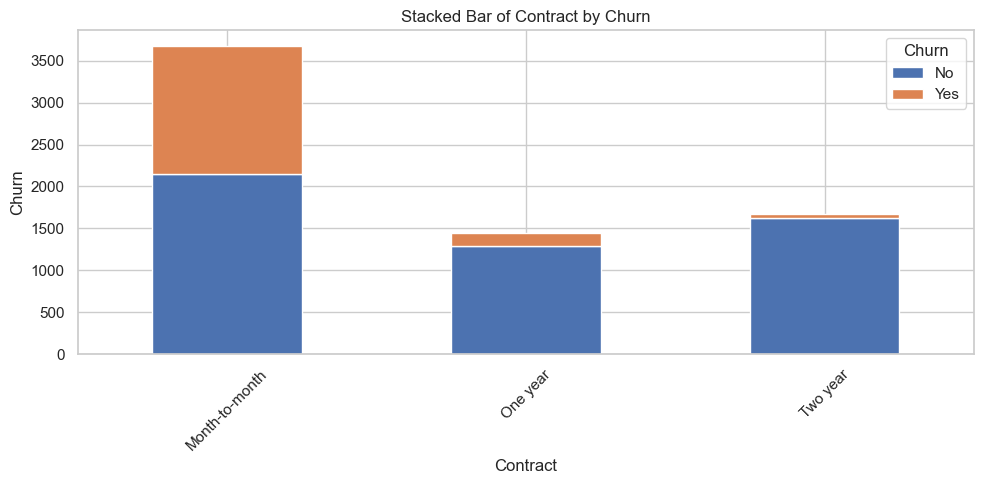

In [265]:
# Visualization
con.plot(kind='bar', stacked=True)

plt.title(f"Stacked Bar of Contract by Churn")
plt.xlabel('Contract')
plt.ylabel("Churn")
plt.xticks(rotation=45)
plt.legend(title='Churn', loc='upper right')
plt.tight_layout()
plt.show()

In [266]:
chi2, p, dof, expected = chi2_contingency(con)

print("\nChi-square test: PaymentMethod vs Churn")
print("Chi-square statistic:", chi2)
print("p-value:", p)
if p < 0.05:
    print('There is association')
else:
    print("***There is no association***")
print("Degrees of freedom:", dof)
print("\nExpected counts:")
print(expected)


Chi-square test: PaymentMethod vs Churn
Chi-square statistic: 1109.2197007477898
p-value: 1.3677363002855846e-241
There is association
Degrees of freedom: 2

Expected counts:
[[2734.69745551  941.30254449]
 [1078.7027504   371.2972496 ]
 [1244.59979409  428.40020591]]


### 2- Correlation Analysis

In [267]:
corr=df_clean.corr(numeric_only=True)
corr

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.245286,0.823021
MonthlyCharges,0.245286,1.000000,0.657234
TotalCharges,0.823021,0.657234,1.000000


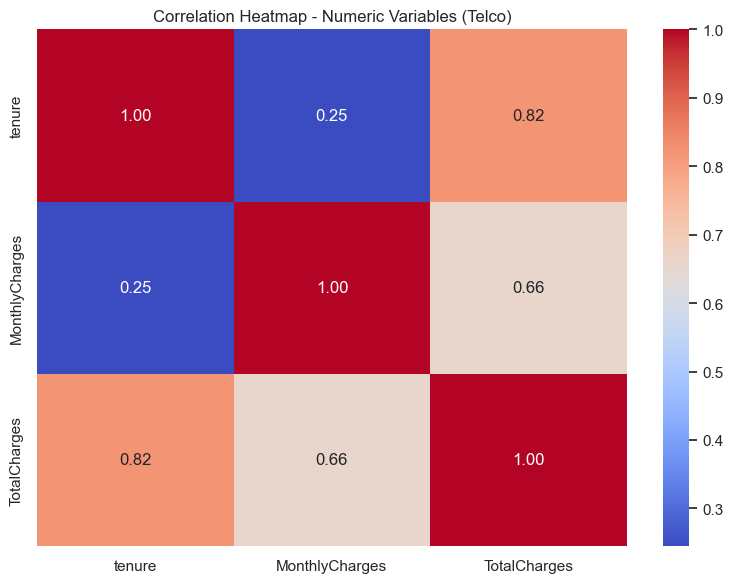

In [268]:
#Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - Numeric Variables (Telco)")
plt.tight_layout()
plt.show()

#### Tenure and TotalCharge have a strong positive correlation.

## Collinearity / Multi-collinearity (VIF)

In [269]:
# Collinearity
df_clean=df_clean.drop(columns=['TotalCharges'])
#TotalCharges is dropped due to high collinearity with tenure

In [270]:
df_clean.shape

(6799, 19)

In [271]:
#Check multi_collinearity
#Select numeric predictors only
X=df_clean[['tenure','MonthlyCharges']]

#Add constant
X=sm.add_constant(X)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

#print result
print("\nVariance Inflation Factors (VIF) - Telco numeric subset:")
print(vif_data)


Variance Inflation Factors (VIF) - Telco numeric subset:
          feature       VIF
0           const  6.445878
1          tenure  1.064017
2  MonthlyCharges  1.064017


The Vif value for the numeric predictors is 1.06, which is far below the common threshold of 10. Thsi indicates no multicollinearity between tenure and MonthlyCharges.

## Encoding Categorical Variables and Target

In [48]:
df_clean

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,Yes


In [272]:

# ======================================
#             ENCODING 
# ======================================

# Target: Churn (Yes/No) -> 1/0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Separate features and target
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

# One-hot encode categorical variables using pandas.get_dummies
X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X_encoded.shape)
print("Encoded feature columns sample:", X_encoded.columns[:10])


Shape after encoding: (6799, 29)
Encoded feature columns sample: Index(['tenure', 'MonthlyCharges', 'gender_Male', 'SeniorCitizen_1',
       'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic'],
      dtype='object')


### Train/Test Split

In [50]:
X_encoded

,tenure,MonthlyCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1,34,56.95,True,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2,53.85,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,45,42.30,True,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,2,70.70,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
5,8,99.65,False,False,False,False,True,False,True,True,...,False,True,False,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,24,84.80,True,False,True,True,True,False,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,72,103.20,False,False,True,True,True,False,True,True,...,False,True,False,True,True,False,True,True,False,False
7040,11,29.60,False,False,True,True,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
7041,4,74.40,True,True,True,False,True,False,True,True,...,False,False,False,False,False,False,True,False,False,True


In [51]:
y

1       0
2       1
3       0
4       1
5       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 6799, dtype: int64

In [273]:

# ==========================
#  TRAIN/TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5439, 29)
Test shape: (1360, 29)


### Scaling

In [274]:
# =======================
#  SCALING THE FEATURES
# =======================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## PCA

In [54]:
# =======================
# 10. PCA ANALYSIS
# =======================

# Fit PCA on scaled training data
pca= PCA()
pca.fit(X_train_scaled)

# Explained variance ratio
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

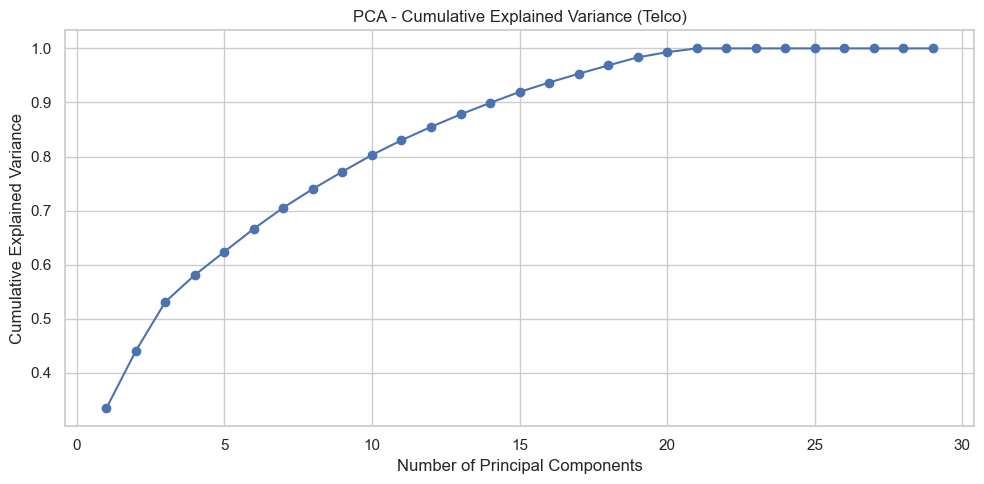

In [55]:
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance (Telco)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
# choose number of components explaining ~95% variance
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Number of components to explain ~95% variance: {n_components_95}")


Number of components to explain ~95% variance: 17


PCA was performed after encoding the categorical variables, resulting in 29 numeric features. The explained variance analysis showed that 17 components were required to retain 95% of the variance. Because this still represents more than half of the original variables, PCA does not provide meaningful dimensionality reduction. Additionally, PCA reduces interpretability, since the transformed components do not correspond to the original features. Therefore, PCA is not recommended for the final model and is used only for exploratory analysis.

# Classification Models

### 1- Logistic Regression

In [69]:
# ----- 1 Logistic Regression -----
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_train_pred = log_reg.predict(X_train_scaled)
y_pred = log_reg.predict(X_test_scaled)
# For ROC curve we need probabilities
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# K-FOLD CROSS-VALIDATION
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_score = cross_val_score(log_reg, X_train, y_train, cv=kf, scoring='accuracy')

print("K-Fold Results (5-fold):")
print("Cross_val_Mean Accuracy:", cv_score.mean())

# TRAIN metric evaluation
print("\nTRAIN SET RESULTS:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred))
print("Classification Report")
print(classification_report(y_train, y_train_pred))

# TEST Evaluation
print("\nTEST SET RESULTS:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("Classification Report")
print(classification_report(y_test, y_pred))

#ROC
print("ROC score:",roc_auc_score(y_test,y_pred_proba))

K-Fold Results (5-fold):
Cross_val_Mean Accuracy: 0.8043767587531793

TRAIN SET RESULTS:
Accuracy: 0.8076852362566648
Confusion Matrix
[[3651  395]
 [ 651  742]]
Classification Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      4046
           1       0.65      0.53      0.59      1393

    accuracy                           0.81      5439
   macro avg       0.75      0.72      0.73      5439
weighted avg       0.80      0.81      0.80      5439


TEST SET RESULTS:
Accuracy: 0.8007352941176471
Confusion Matrix
[[909 103]
 [168 180]]
Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1012
           1       0.64      0.52      0.57       348

    accuracy                           0.80      1360
   macro avg       0.74      0.71      0.72      1360
weighted avg       0.79      0.80      0.79      1360

ROC score: 0.8359030711916768


###  Viaualization

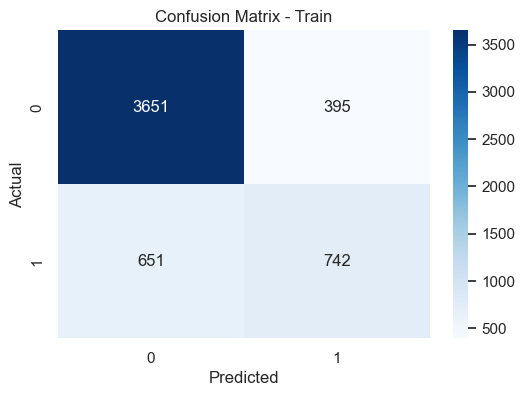

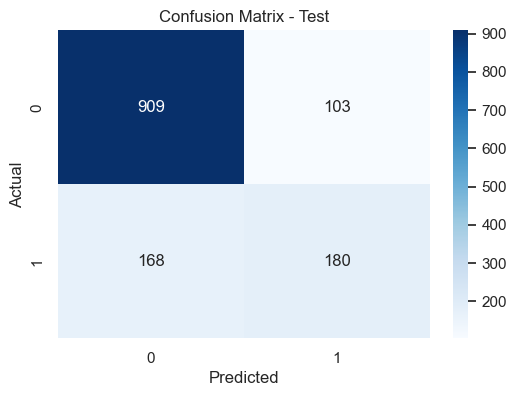

In [70]:
# Confusion matrix

#for train dataset
cm1 = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Train")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("logreg_train_cm1.png", dpi=300, bbox_inches='tight')
plt.show()

#for test dataset
cm2 = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("logreg_test_cm1.png", dpi=300, bbox_inches='tight')
plt.show()

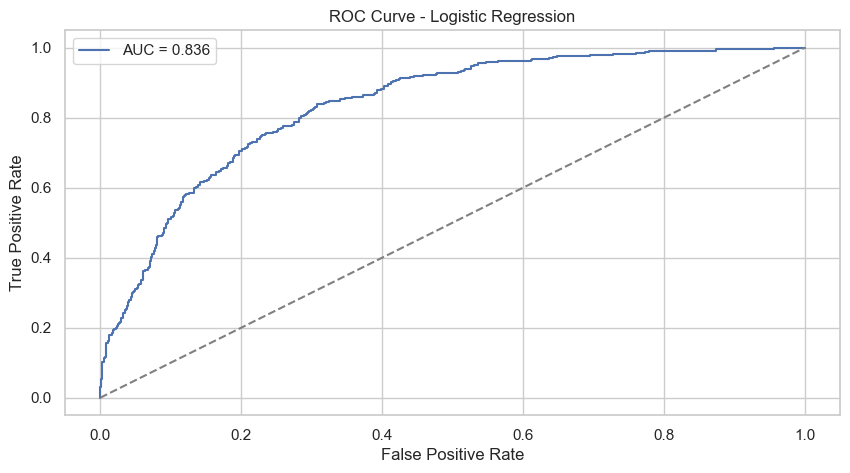

AUC Score: 0.8359030711916768


In [71]:
 # ROC Curve + AUC
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.savefig("Roc_curve1.png", dpi=300, bbox_inches='tight')
plt.show()

print("AUC Score:", auc)

The Logistic Regression model demonstrated stable and reliable performance across all evaluation methods. The 5-fold cross-validation results (mean accuracy ≈ 80%) indicate consistent behavior across multiple splits. Train and test accuracies were almost identical (80.8% vs. 80.1%), showing no evidence of overfitting and confirming that the model generalizes well to unseen data. Analysis of the confusion matrices revealed measurable error rates: on the train set, the model produced 9.76% Type I errors (predicting churn when the customer actually stayed) and 46.7% Type II errors (failing to detect true churners). On the test set, it produced 10.2% Type I errors and 48.3 Type II errors.In churn prediction, Type II error is considered worse because missing a churner means the business loses a customer and cannot take retention action, whereas Type I error only results in offering unnecessary incentives, which is far less costly. So we shall do some grid search parameteres that would reduce the Type II error.

#### GridSearch 

In [65]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced',{0:1,1:2}]}

In [77]:
#Gridsearch
log_reg = LogisticRegression(max)

grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring='recall',    
    cv=5,
    n_jobs=-1)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Recall Score:", grid.best_score_)

Best Parameters: {'C': 0.001, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best Recall Score: 0.8370464918387871


In [80]:
# Train model with the best_parameteres
best_reg = LogisticRegression(max_iter=1000,C=0.001,class_weight='balanced',penalty='l2',solver='liblinear')
best_reg.fit(X_train_scaled, y_train)
y_train_pred = best_reg.predict(X_train_scaled)
y_pred = best_reg.predict(X_test_scaled)
# For ROC curve we need probabilities
y_pred_proba = best_reg.predict_proba(X_test_scaled)[:, 1]


# TRAIN metric evaluation
print("\nRESULTS AFTER GRIDSEARCH")
print("\nTRAIN SET RESULTS:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred))
print("Classification Report")
print(classification_report(y_train, y_train_pred))


# TEST Evaluation

print("\nTEST SET RESULTS:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("Classification Report")
print(classification_report(y_test, y_pred))

#ROC
print("ROC Score:",roc_auc_score(y_test,y_pred_proba))



RESULTS AFTER GRIDSEARCH

TRAIN SET RESULTS:
Accuracy: 0.7150211435925722
Confusion Matrix
[[2727 1319]
 [ 231 1162]]
Classification Report
              precision    recall  f1-score   support

           0       0.92      0.67      0.78      4046
           1       0.47      0.83      0.60      1393

    accuracy                           0.72      5439
   macro avg       0.70      0.75      0.69      5439
weighted avg       0.81      0.72      0.73      5439


TEST SET RESULTS:
Accuracy: 0.7066176470588236
Confusion Matrix
[[664 348]
 [ 51 297]]
Classification Report
              precision    recall  f1-score   support

           0       0.93      0.66      0.77      1012
           1       0.46      0.85      0.60       348

    accuracy                           0.71      1360
   macro avg       0.69      0.75      0.68      1360
weighted avg       0.81      0.71      0.73      1360

ROC Score: 0.8348836945163781


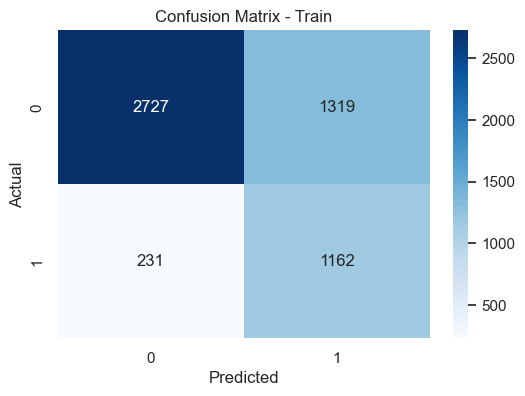

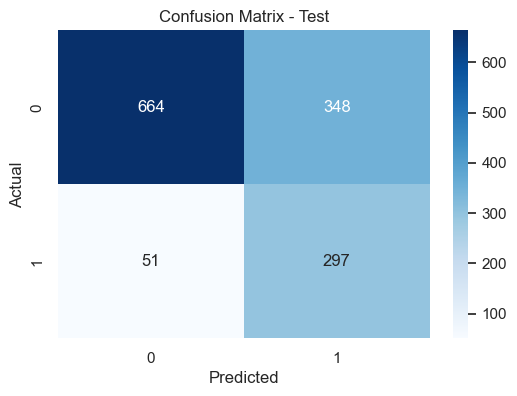

In [82]:
# Confusion matrix

#for train dataset
cm1 = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Train")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("logreg_train_cm2.png", dpi=300, bbox_inches='tight')
plt.show()

#for train dataset
cm2 = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("logreg_test_cm2.png", dpi=300, bbox_inches='tight')
plt.show()

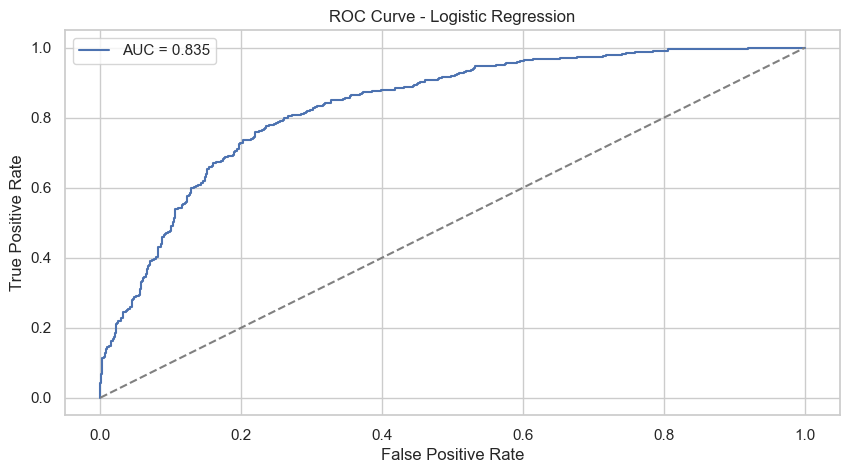

AUC Score: 0.8348836945163781


In [83]:
 # ROC Curve + AUC
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.savefig("Roc_curve2.png", dpi=300, bbox_inches='tight')
plt.show()
print("AUC Score:", auc)


After tuning the Logistic Regression model using recall as the optimization metric, Type II error decreased significantly—from 48% to 14% false negatives—indicating that the model is now much better at identifying customers who are likely to churn with auc score of 83.5%. However, this improvement came with a trade-off: Type I error increased from 10% to 34% false positives. This behavior is expected because increasing recall makes the model more aggressive in predicting churn. In churn prediction, this trade-off is acceptable, and even desirable, because Type II error (missing a churner) is far more costly to the business than Type I error (flagging a non-churner). Therefore, despite the increase in Type I error and the decrease in overall accuracy, the tuned model provides better business value by successfully capturing more actual churners.

In [84]:
# feature importance

# Get coefficients from the trained logistic regression model
coefficients = best_reg.coef_[0]  # or model.coef_[0]
feature_names = X_train.columns

# Create a DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute value (strongest impact on churn)
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
coef_df

,Feature,Coefficient,Abs_Coefficient
0,tenure,-0.319831,0.319831
24,Contract_Two year,-0.229290,0.229290
9,InternetService_Fiber optic,0.186747,0.186747
23,Contract_One year,-0.153949,0.153949
27,PaymentMethod_Electronic check,0.147484,0.147484
12,OnlineSecurity_Yes,-0.139210,0.139210
18,TechSupport_Yes,-0.120630,0.120630
25,PaperlessBilling_Yes,0.107763,0.107763
1,MonthlyCharges,0.078353,0.078353
14,OnlineBackup_Yes,-0.076436,0.076436


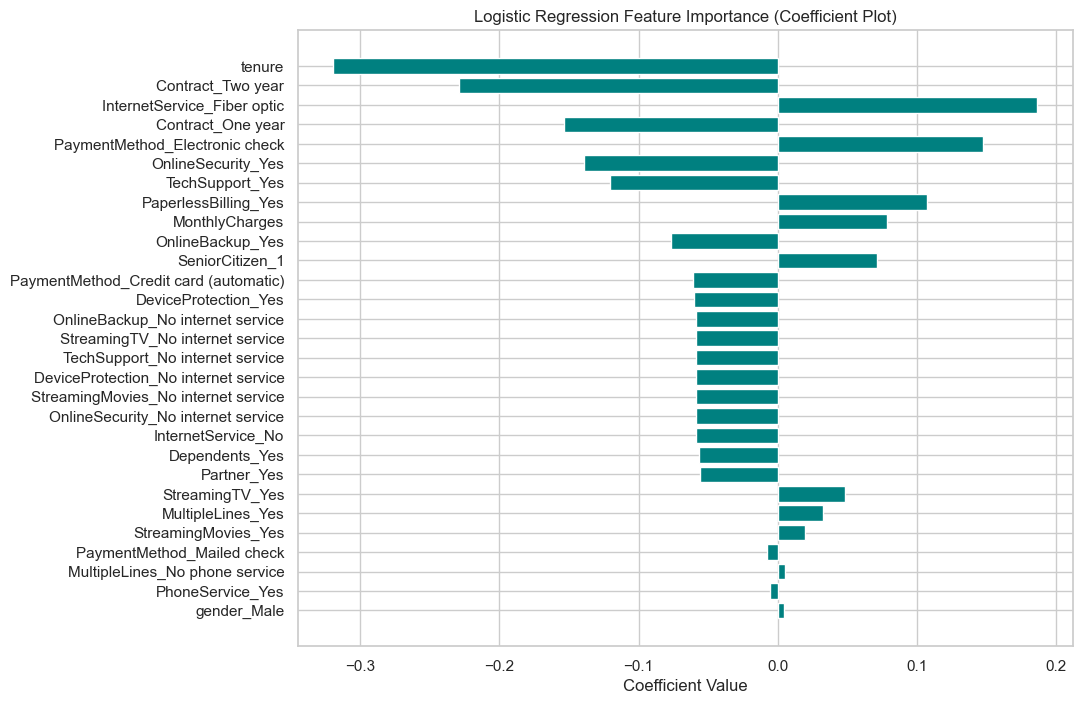

In [86]:
#visualization
plt.figure(figsize=(10,8))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='teal')
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Importance (Coefficient Plot)")
plt.gca().invert_yaxis()  # Largest coefficient on top
plt.savefig("log_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()


The coefficient analysis from the Logistic Regression model shows several key factors influencing customer churn. Tenure is the strongest predictor, with a large negative coefficient, indicating that long-standing customers are significantly less likely to churn. Likewise, both One-year and Two-year contracts strongly reduce churn probability, confirming that longer contractual commitments increase customer retention. In contrast, customers using Fiber optic internet service have a higher likelihood of churning, possibly due to higher pricing or service quality expectations. Payment method also plays a role: customers paying with Electronic check are more likely to churn, while those using more stable methods such as credit card or bank transfer show lower churn risk. Engagement with value-added services such as Online Security, Tech Support, and Device Protection lowers churn probability, whereas lack of these services (e.g., No Online Security, No Tech Support, No Internet Service) contributes modestly to churn risk.

Moderate effects were also observed for features like Paperless Billing, which slightly increases churn, and Monthly Charges, where higher bills are associated with higher churn. Customer demographics such as SeniorCitizen, Partner, and Dependents show small negative coefficients, suggesting a slightly lower likelihood of churn among these groups. Service usage characteristics including StreamingTV, StreamingMovies, and MultipleLines have comparatively smaller coefficients, indicating limited influence on churn. Finally, variables such as gender, payment by mailed check, and phone service show minimal predictive power with near-zero coefficients. Overall, the model indicates that churn is primarily driven by contract type, tenure, internet service type, billing/payment behaviors, and engagement in optional security/support services, while demographic factors and some service add-ons play a minor role.

### 2-KNN

In [92]:
# ----- 2 KNN Classifier -----
# Instantiate model 
knn = KNeighborsClassifier()

# Fit model on TRAIN set
knn.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_knn = knn.predict(X_train_scaled)
y_test_pred_knn = knn.predict(X_test_scaled)

# For ROC curve probabilities
y_test_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

# ============================
# K-FOLD CROSS-VALIDATION
# ============================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_knn = cross_val_score(knn, X_train, y_train, cv=kf)

print("K-Fold Results (5-fold):")
print("Cross_val_Mean Accuracy:", cv_scores_knn.mean())

# ============================
# TRAIN SET RESULTS
# ============================
print("\nTRAIN SET RESULTS:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_knn))

train_cm = confusion_matrix(y_train, y_train_pred_knn)
print("Confusion Matrix:\n", train_cm)

print("Classification Report:")
print(classification_report(y_train, y_train_pred_knn))

# ============================
# TEST SET RESULTS
# ============================
print("\nTEST SET RESULTS:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_knn))

test_cm = confusion_matrix(y_test, y_test_pred_knn)
print("Confusion Matrix:\n", test_cm)

print("Classification Report:")
print(classification_report(y_test, y_test_pred_knn))

# ============================
# ROC-AUC Score
# ============================
print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba_knn))

K-Fold Results (5-fold):
Cross_val_Mean Accuracy: 0.7767981560149358

TRAIN SET RESULTS:
Accuracy: 0.8260709689281118
Confusion Matrix:
 [[3647  399]
 [ 547  846]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      4046
           1       0.68      0.61      0.64      1393

    accuracy                           0.83      5439
   macro avg       0.77      0.75      0.76      5439
weighted avg       0.82      0.83      0.82      5439


TEST SET RESULTS:
Accuracy: 0.75
Confusion Matrix:
 [[850 162]
 [178 170]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.83      1012
           1       0.51      0.49      0.50       348

    accuracy                           0.75      1360
   macro avg       0.67      0.66      0.67      1360
weighted avg       0.75      0.75      0.75      1360

ROC-AUC Score: 0.763958929626096


The initial KNN model achieved approximately 82% accuracy on the training set, but only 75–76% accuracy on the test set, indicating a noticeable performance gap. This difference suggests overfitting, meaning the model is fitting the training data too closely and is not generalizing well to new, unseen data. KNN is highly sensitive to its hyperparameters, especially the number of neighbors (k), Therefore, further hyperparameter tuning—such as adjusting k, experimenting with distance functions, and applying different weighting schemes—is needed to improve generalization and reduce overfitting. GridSearchCV will be used to identify the optimal combination of parameters that produce a more balanced performance between training and test accuracy.

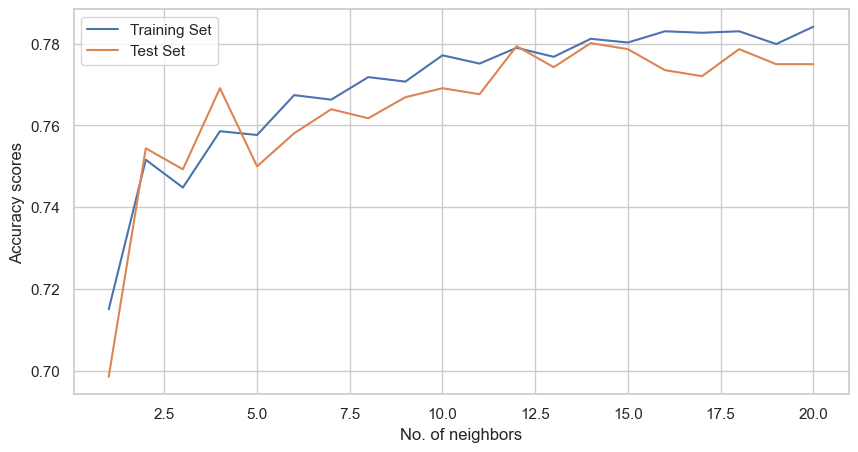

In [97]:
#find the optimal value of k
train_scores = []
test_scores = []
for i in range(1,21,1):
    knn2 = KNeighborsClassifier(n_neighbors=i, weights='uniform')
    train_scores.append(cross_val_score(knn2,X_train_scaled,y_train,cv=5).mean())
    knn2.fit(X_train_scaled,y_train)
    test_scores.append(knn2.score(X_test_scaled, y_test))

plt.plot(range(1,21,1),train_scores, label = "Training Set")
plt.plot(range(1,21,1),test_scores, label = "Test Set")
plt.xlabel('No. of neighbors')
plt.ylabel('Accuracy scores')
plt.legend()
plt.show()

    

In [160]:
# Best estimator
best_knn=KNeighborsClassifier(n_neighbors=14)
best_knn.fit(X_train_scaled,y_train)

# -------------------------------
# TRAIN SET RESULTS
# -------------------------------
y_train_pred_knn = best_knn.predict(X_train_scaled)

print("\nTRAIN SET RESULTS:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_knn))
train_cm = confusion_matrix(y_train, y_train_pred_knn)
print("Confusion Matrix:\n", train_cm)
print("Classification Report:")
print(classification_report(y_train, y_train_pred_knn))

# Type I & II (Train)
TN, FP, FN, TP = train_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

# -------------------------------
# TEST SET RESULTS
# -------------------------------
y_test_pred_knn = best_knn.predict(X_test_scaled)
y_test_proba_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

print("\nTEST SET RESULTS:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_knn))

test_cm = confusion_matrix(y_test, y_test_pred_knn)
print("Confusion Matrix:\n", test_cm)
print("Classification Report:")
print(classification_report(y_test, y_test_pred_knn))

# Type I & II (Test)
TN, FP, FN, TP = test_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

# ROC-AUC
print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba_knn))


TRAIN SET RESULTS:
Accuracy: 0.810075381503953
Confusion Matrix:
 [[3677  369]
 [ 664  729]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      4046
           1       0.66      0.52      0.59      1393

    accuracy                           0.81      5439
   macro avg       0.76      0.72      0.73      5439
weighted avg       0.80      0.81      0.80      5439

Type I Error (FP): 369
Type II Error (FN): 664

TEST SET RESULTS:
Accuracy: 0.7801470588235294
Confusion Matrix:
 [[895 117]
 [182 166]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1012
           1       0.59      0.48      0.53       348

    accuracy                           0.78      1360
   macro avg       0.71      0.68      0.69      1360
weighted avg       0.77      0.78      0.77      1360

Type I Error (FP): 117
Type II Error (FN): 182
ROC-AUC Score: 0.80509

KNN consistently produced high Type II error (false negatives) across all scoring methods, indicating that the model struggles to detect churners. This happens because churn datasets are imbalanced. In addition, one-hot encoded categorical variables increase dimensionality and distort distance calculations, which further reduces KNN’s ability to properly identify minority patterns. To address this limitation, SMOTE oversampling was applied to the training data to synthetically generate churn samples, giving KNN a more balanced distribution of neighbors. This helps the model better learn churn patterns and significantly reduces Type II error by ensuring that minority-class samples are not overwhelmed during neighbor voting.

In [119]:
from imblearn.over_sampling import SMOTE

In [120]:
# ----- 3 KNN WITH SMOTE -----

# =============================
# APPLY SMOTE ON TRAINING DATA
# =============================
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())


Before SMOTE: Churn
0    4046
1    1393
Name: count, dtype: int64
After SMOTE: Churn
1    4046
0    4046
Name: count, dtype: int64


In [167]:
knn_smote = KNeighborsClassifier(n_neighbors=14)
knn_smote.fit(X_train_resampled, y_train_resampled)

# -------------------------------
# TRAIN SET RESULTS
# -------------------------------
y_train_pred_knn = best_knn.predict(X_train_resampled)

print("\nTRAIN SET RESULTS:")
print("Accuracy:", accuracy_score(y_train_resampled, y_train_pred_knn))
train_cm = confusion_matrix(y_train_resampled, y_train_pred_knn)
print("Confusion Matrix:\n", train_cm)
print("Classification Report:")
print(classification_report(y_train_resampled, y_train_pred_knn))

# Type I & II (Train)
TN, FP, FN, TP = train_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

# -------------------------------
# TEST SET RESULTS
# -------------------------------
y_test_pred_knn = best_knn.predict(X_test_scaled)
y_test_proba_knn = best_knn.predict_proba(X_test_scaled)[:, 1]
print("\nTEST SET RESULTS:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_knn))

test_cm = confusion_matrix(y_test, y_test_pred_knn)
print("Confusion Matrix:\n", test_cm)


TRAIN SET RESULTS:
Accuracy: 0.7366534849233811
Confusion Matrix:
 [[3677  369]
 [1762 2284]]
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.91      0.78      4046
           1       0.86      0.56      0.68      4046

    accuracy                           0.74      8092
   macro avg       0.77      0.74      0.73      8092
weighted avg       0.77      0.74      0.73      8092

Type I Error (FP): 369
Type II Error (FN): 1762

TEST SET RESULTS:
Accuracy: 0.7801470588235294
Confusion Matrix:
 [[895 117]
 [182 166]]


In [129]:
# Best estimator
best_knn = grid_knn.best_estimator_


print("Classification Report:")
print(classification_report(y_test, y_test_pred_knn))

# Type I & II (Test)
TN, FP, FN, TP = test_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

# ROC-AUC
print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba_knn))



TRAIN SET RESULTS:
Accuracy: 0.9970582827725685
Confusion Matrix:
 [[4046    0]
 [  16 1377]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4046
           1       1.00      0.99      0.99      1393

    accuracy                           1.00      5439
   macro avg       1.00      0.99      1.00      5439
weighted avg       1.00      1.00      1.00      5439

Type I Error (FP): 0
Type II Error (FN): 16

TEST SET RESULTS:
Accuracy: 0.7235294117647059
Confusion Matrix:
 [[761 251]
 [125 223]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80      1012
           1       0.47      0.64      0.54       348

    accuracy                           0.72      1360
   macro avg       0.66      0.70      0.67      1360
weighted avg       0.76      0.72      0.74      1360

Type I Error (FP): 251
Type II Error (FN): 125
ROC-AUC Score: 0.7709383

After applying SMOTE, KNN achieved extremely high training accuracy (99.7%) with zero false positives in the training set, which clearly indicates severe overfitting. The test set results, however, show a much lower accuracy of 72%, along with a high number of false positives (251) and false negatives (125). Although SMOTE increased recall for the minority class, it also caused KNN to become overly sensitive to synthetic samples, leading to poor generalization. This confirms that KNN is not well-suited for this churn dataset due to its susceptibility to overfitting, sensitivity to high-dimensional encoded features, and instability under class imbalance conditions. Overall, Logistic Regression model provide stronger, more reliable performance than KNN for this problem.

## 3 RandomForest

In [150]:
# Instantiate model
rf = RandomForestClassifier( random_state=42, n_jobs=-1)

# Fit model
rf.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# Probabilities for ROC
y_test_proba_rf = rf.predict_proba(X_test)[:, 1]

# ============================
# 5-FOLD CROSS VALIDATION
# ============================
kf = KFold(n_splits=4, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=kf, scoring='roc_auc')

print("K-Fold Results (5-fold):")
print("Cross_val_Mean Accuracy:", cv_scores_rf.mean())

# ============================
# TRAIN SET RESULTS
# ============================
print("\nTRAIN SET RESULTS:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_rf))

train_cm = confusion_matrix(y_train, y_train_pred_rf)
print("Confusion Matrix:\n", train_cm)
print("Classification Report:")
print(classification_report(y_train, y_train_pred_rf))

TN, FP, FN, TP = train_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

# ============================
# TEST SET RESULTS
# ============================
print("\nTEST SET RESULTS:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf))

test_cm = confusion_matrix(y_test, y_test_pred_rf)
print("Confusion Matrix:\n", test_cm)
print("Classification Report:")
print(classification_report(y_test, y_test_pred_rf))

TN, FP, FN, TP = test_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

# ROC-AUC
print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba_rf))

K-Fold Results (5-fold):
Cross_val_Mean Accuracy: 0.8168085661467535

TRAIN SET RESULTS:
Accuracy: 0.9970582827725685
Confusion Matrix:
 [[4038    8]
 [   8 1385]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4046
           1       0.99      0.99      0.99      1393

    accuracy                           1.00      5439
   macro avg       1.00      1.00      1.00      5439
weighted avg       1.00      1.00      1.00      5439

Type I Error (FP): 8
Type II Error (FN): 8

TEST SET RESULTS:
Accuracy: 0.7801470588235294
Confusion Matrix:
 [[915  97]
 [202 146]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1012
           1       0.60      0.42      0.49       348

    accuracy                           0.78      1360
   macro avg       0.71      0.66      0.68      1360
weighted avg       0.76      0.78      0.77      1360

Typ

The initial Random Forest model shows clear signs of overfitting. The training accuracy is extremely high (99.7%), with very small error rates (FP = 9 and FN = 7), indicating that the model is fitting the training data almost perfectly. However, the test accuracy drops to 78%, and the test confusion matrix reveals a much weaker performance on unseen data, particularly with a high number of false negatives (FN = 201), which means the model is missing many churners. The large gap between training and test performance confirms that the model is overfitting. Additionally, the recall for the churn class drops to 0.42 on the test set, showing that the model struggles to generalize its ability to identify churners. To address this issue, it is necessary to perform hyperparameter tuning using GridSearchCV to find better parameters—such as adjusting the number of trees, maximum depth, and minimum samples per split—to improve generalization and reduce overfitting.

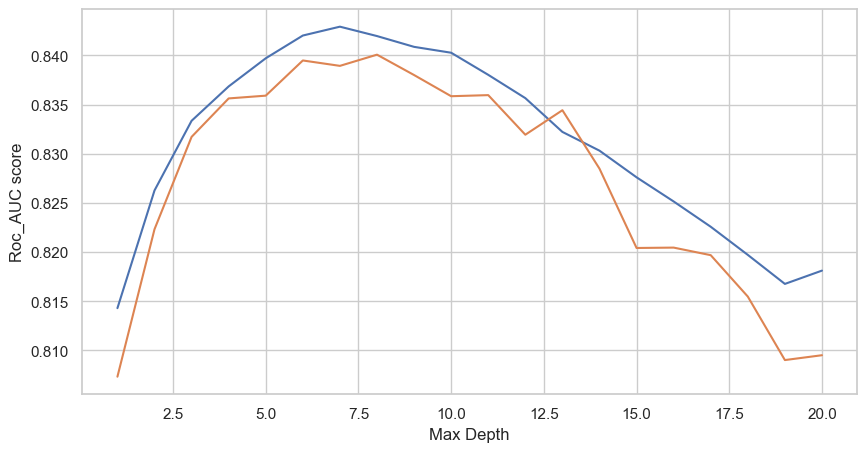

In [134]:
# Pre Search on max depth
train_cv = []
test = []
for depth in range(1,21):
    rf = RandomForestClassifier(max_depth = depth, class_weight = "balanced", n_jobs = -1, random_state=42)
    train_cv.append(cross_val_score(rf, X_train, y_train, scoring = "roc_auc", cv=4).mean())
    rf.fit(X_train, y_train)
    #preds = rf.predict(X_test)
    pred_proba = rf.predict_proba(X_test)[:, 1]
    test.append(roc_auc_score(y_test, pred_proba))

plt.plot(range(1,21), train_cv, label = "Train Cross Val roc_auc")
plt.plot(range(1,21), test, label = "Test roc_auc")
plt.xlabel("Max Depth")
plt.ylabel("Roc_AUC score")
                
plt.show()

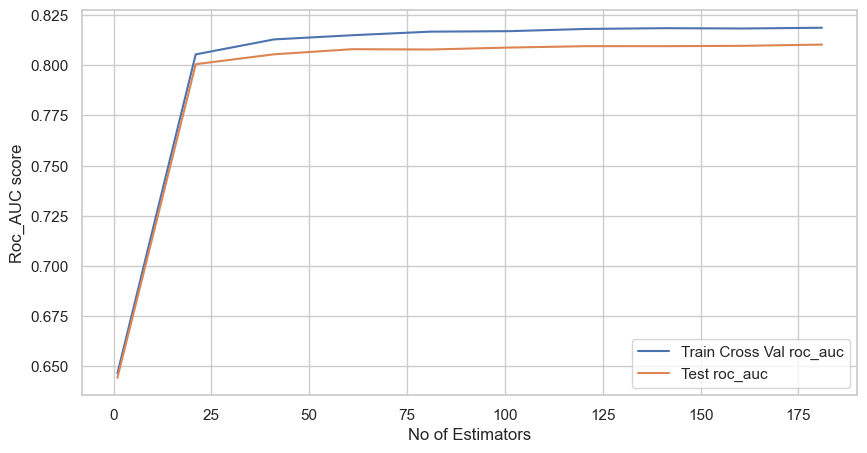

In [136]:
# Pre Search on no of estimators
train_cv = []
test = []
for trees in range(1,201,20):
    rf = RandomForestClassifier(n_estimators=trees, class_weight = "balanced", n_jobs = -1, random_state=42)
    train_cv.append(cross_val_score(rf, X_train, y_train, scoring = "roc_auc", cv=4).mean())
    rf.fit(X_train, y_train)
    #preds = rf.predict(X_test)
    pred_proba = rf.predict_proba(X_test)[:, 1]
    test.append(roc_auc_score(y_test, pred_proba))

plt.plot(range(1,201,20), train_cv, label = "Train Cross Val roc_auc")
plt.plot(range(1,201,20), test, label = "Test roc_auc")
plt.xlabel("No of Estimators")
plt.ylabel("Roc_AUC score")
plt.legend()             
plt.show()

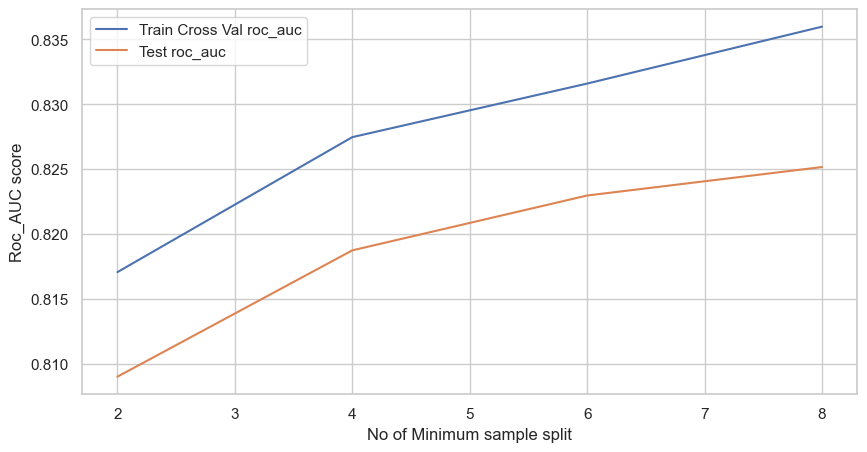

In [140]:
# Pre Search on no of min_sample split
train_cv = []
test = []
for split in range(2,10,2):
    rf = RandomForestClassifier(min_samples_split=split, class_weight = "balanced", n_jobs = -1, random_state=42)
    train_cv.append(cross_val_score(rf, X_train, y_train, scoring = "roc_auc", cv=4).mean())
    rf.fit(X_train, y_train)
    #preds = rf.predict(X_test)
    pred_proba = rf.predict_proba(X_test)[:, 1]
    test.append(roc_auc_score(y_test, pred_proba))

plt.plot(range(2,10,2), train_cv, label = "Train Cross Val roc_auc")
plt.plot(range(2,10,2), test, label = "Test roc_auc")
plt.xlabel("No of Minimum sample split")
plt.ylabel("Roc_AUC score")
plt.legend()             
plt.show()

In [155]:
param_grid_rf = {'n_estimators':[50,75,100,125,150],
            'max_depth':[3,5,6,8,13],
           "min_samples_split": [2,4,6,8] }

In [156]:
 rf = RandomForestClassifier( class_weight = "balanced", n_jobs = -1, random_state=42)
# Grid search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=4,
    scoring='roc_auc',  
    n_jobs=-1)

# Fit grid search 
grid_rf.fit(X_train, y_train)

# BEST PARAMETERS
print("Best Parameters:", grid_rf.best_params_)
print("Best  Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 8, 'min_samples_split': 4, 'n_estimators': 125}
Best  Score: 0.8430255844255756


In [157]:
# Instantiate model
rf_best= RandomForestClassifier( random_state=42, n_jobs=-1,max_depth= 8, min_samples_split= 4, n_estimators= 125)

# Fit model
rf_best.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_best.predict(X_train)
y_test_pred_rf = rf_best.predict(X_test)

# Probabilities for ROC
y_test_proba_rf = rf_best.predict_proba(X_test)[:, 1]

# ============================
# 5-FOLD CROSS VALIDATION
# ============================
kf = KFold(n_splits=4, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=kf,scoring='roc_auc')

print("K-Fold Results (5-fold):")
print("Cross_val_Mean Accuracy:", cv_scores_rf.mean())

# ============================
# TRAIN SET RESULTS
# ============================
print("\nTRAIN SET RESULTS:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_rf))

train_cm = confusion_matrix(y_train, y_train_pred_rf)
print("Confusion Matrix:\n", train_cm)
print("Classification Report:")
print(classification_report(y_train, y_train_pred_rf))

TN, FP, FN, TP = train_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

# ============================
# TEST SET RESULTS
# ============================
print("\nTEST SET RESULTS:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf))

test_cm = confusion_matrix(y_test, y_test_pred_rf)
print("Confusion Matrix:\n", test_cm)
print("Classification Report:")
print(classification_report(y_test, y_test_pred_rf))

TN, FP, FN, TP = test_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

# ROC-AUC
print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba_rf))


K-Fold Results (5-fold):
Cross_val_Mean Accuracy: 0.8170770314395394

TRAIN SET RESULTS:
Accuracy: 0.8325059753631182
Confusion Matrix:
 [[3780  266]
 [ 645  748]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      4046
           1       0.74      0.54      0.62      1393

    accuracy                           0.83      5439
   macro avg       0.80      0.74      0.76      5439
weighted avg       0.82      0.83      0.82      5439

Type I Error (FP): 266
Type II Error (FN): 645

TEST SET RESULTS:
Accuracy: 0.7970588235294118
Confusion Matrix:
 [[926  86]
 [190 158]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1012
           1       0.65      0.45      0.53       348

    accuracy                           0.80      1360
   macro avg       0.74      0.68      0.70      1360
weighted avg       0.78      0.80      0.78      1360


## 4 SVM

In [294]:
# ----- 5 SVM CLASSIFIER -----

# Instantiate model 
svm_clf = SVC(probability=True, random_state=42)

# Fit model
svm_clf.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_svm = svm_clf.predict(X_train_scaled)
y_test_pred_svm  = svm_clf.predict(X_test_scaled)

# Probabilities for ROC
y_test_proba_svm = svm_clf.predict_proba(X_test_scaled)[:, 1]

# ============================
# K-FOLD CROSS VALIDATION
# ============================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_svm = cross_val_score(svm_clf, X_train_scaled, y_train, cv=kf, scoring='accuracy')

print("K-Fold Results (5-fold):")
print("Cross_val_Mean Accuracy:", cv_scores_svm.mean())

# ============================
# TRAIN SET RESULTS
# ============================
print("\nTRAIN SET RESULTS:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_svm))

train_cm_svm = confusion_matrix(y_train, y_train_pred_svm)
print("Confusion Matrix:\n", train_cm_svm)
print("Classification Report:")
print(classification_report(y_train, y_train_pred_svm))

TN, FP, FN, TP = train_cm_svm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

# ============================
# TEST SET RESULTS
# ============================
print("\nTEST SET RESULTS:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_svm))

test_cm_svm = confusion_matrix(y_test, y_test_pred_svm)
print("Confusion Matrix:\n", test_cm_svm)
print("Classification Report:")
print(classification_report(y_test, y_test_pred_svm))

TN, FP, FN, TP = test_cm_svm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

# ROC-AUC
print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba_svm))

K-Fold Results (5-fold):
Cross_val_Mean Accuracy: 0.801985869094648

TRAIN SET RESULTS:
Accuracy: 0.8225776797205369
Confusion Matrix:
 [[3737  309]
 [ 656  737]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.92      0.89      4046
           1       0.70      0.53      0.60      1393

    accuracy                           0.82      5439
   macro avg       0.78      0.73      0.74      5439
weighted avg       0.81      0.82      0.81      5439

Type I Error (FP): 309
Type II Error (FN): 656

TEST SET RESULTS:
Accuracy: 0.7977941176470589
Confusion Matrix:
 [[920  92]
 [183 165]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1012
           1       0.64      0.47      0.55       348

    accuracy                           0.80      1360
   macro avg       0.74      0.69      0.71      1360
weighted avg       0.78      0.80      0.79      1360



The SVM  achieved reasonable performance, with a cross-validation accuracy of 79.9% and a test accuracy of 78.6%. The ROC-AUC score of 0.81 indicates good overall classification ability. However, similar to the Random Forest model, the polynomial SVM shows a high Type II error (FN = 183), correctly identifying only 47% of churn customers.Although the model demonstrates stable generalization with no overfitting, its relatively low recall for churn and high Type II error make it less suitable for applications where identifying churners is critical. To address this issue, it is necessary to perform hyperparameter tuning using GridSearchCV to find better parameters.

#### Gridsearch

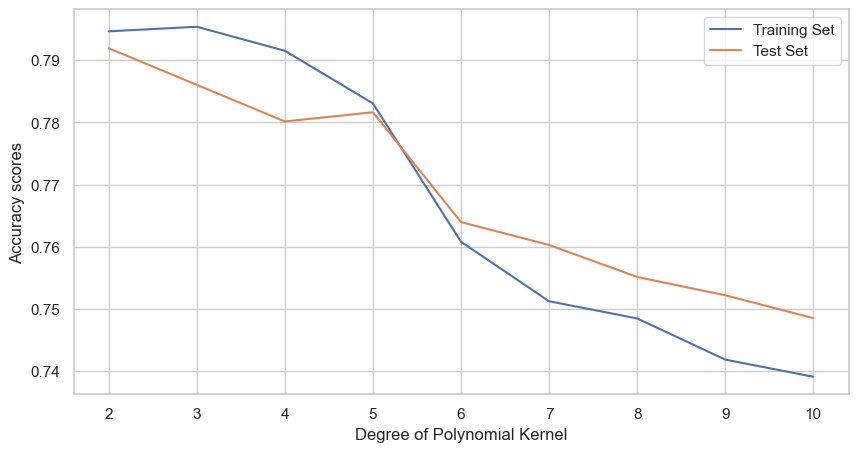

In [295]:
train_scores = []
test_scores = []
for deg in range(2,11):
    clf = SVC(kernel = 'poly', degree = deg)
    train_scores.append(cross_val_score(clf,X_train_scaled,y_train,cv=5).mean())
    clf.fit(X_train_scaled,y_train)
    test_scores.append(clf.score(X_test_scaled, y_test))
plt.plot(range(2,11,1),train_scores, label = "Training Set")
plt.plot(range(2,11,1),test_scores, label = "Test Set")
plt.xlabel('Degree of Polynomial Kernel')
plt.ylabel('Accuracy scores')
plt.legend()
plt.show()

In [ ]:
# ------------------------------
# PARAMETER GRID FOR SVM ()
# ------------------------------
param_grid_svm = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001]}

svm = SVC(kernel='poly', probability=True, random_state=42,degree=True)

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1)

# ------------------------------
# FIT GRIDSEARCH
# ------------------------------
grid_svm.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_svm.best_params_)
print("Best Score:", grid_svm.best_score_)

In [ ]:
# Use best parameteres
best_svm = grid_svm.best_estimator_

# Predictions
y_train_pred = best_svm.predict(X_train_scaled)
y_test_pred = best_svm.predict(X_test_scaled)

# Probabilities for ROC
y_test_proba = best_svm.predict_proba(X_test_scaled)[:, 1]

# ------------------------------
# TRAIN RESULTS
# ------------------------------
print("\nTRAIN SET RESULTS:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))

train_cm = confusion_matrix(y_train, y_train_pred)
print("Confusion Matrix:\n", train_cm)
print("Classification Report:\n", classification_report(y_train, y_train_pred))

TN, FP, FN, TP = train_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

# ------------------------------
# TEST RESULTS
# ------------------------------
print("\nTEST SET RESULTS:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))

test_cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", test_cm)
print("Classification Report:\n", classification_report(y_test, y_test_pred))

TN, FP, FN, TP = test_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

print("\nROC-AUC Score:", roc_auc_score(y_test, y_test_proba))


## 5 ADA BOOST

In [279]:
# -----  ADA BOOST CLASSIFIER -----

# Base estimator 
dt = DecisionTreeClassifier(max_depth=1)

# AdaBoost Model
ada = AdaBoostClassifier( estimator=dt, random_state=42)

# Fit model
ada.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_ada = ada.predict(X_train_scaled)
y_test_pred_ada = ada.predict(X_test_scaled)

# Probabilities for AUC
y_test_proba_ada = ada.predict_proba(X_test_scaled)[:, 1]

# ============================
# 5- FOLD CROSS VALIDATION
# ============================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_ada = cross_val_score(
    ada, X_train_scaled, y_train,
    cv=kf, scoring='accuracy'
)

print("K-Fold Results (5-fold):")
print("Cross_val_Mean Accuracy:", cv_scores_ada.mean())

# ============================
# TRAIN RESULTS
# ============================
print("\nTRAIN SET RESULTS:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_ada))

train_cm = confusion_matrix(y_train, y_train_pred_ada)
print("Confusion Matrix:\n", train_cm)
print("Classification Report:\n", classification_report(y_train, y_train_pred_ada))

TN, FP, FN, TP = train_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

# ============================
# TEST RESULTS
# ============================
print("\nTEST SET RESULTS:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_ada))

test_cm = confusion_matrix(y_test, y_test_pred_ada)
print("Confusion Matrix:\n", test_cm)
print("Classification Report:\n", classification_report(y_test, y_test_pred_ada))

TN, FP, FN, TP = test_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba_ada))

K-Fold Results (5-fold):
Cross_val_Mean Accuracy: 0.8063974646896476

TRAIN SET RESULTS:
Accuracy: 0.8120978120978121
Confusion Matrix:
 [[3704  342]
 [ 680  713]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.92      0.88      4046
           1       0.68      0.51      0.58      1393

    accuracy                           0.81      5439
   macro avg       0.76      0.71      0.73      5439
weighted avg       0.80      0.81      0.80      5439

Type I Error (FP): 342
Type II Error (FN): 680

TEST SET RESULTS:
Accuracy: 0.7875
Confusion Matrix:
 [[911 101]
 [188 160]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1012
           1       0.61      0.46      0.53       348

    accuracy                           0.79      1360
   macro avg       0.72      0.68      0.69      1360
weighted avg       0.77      0.79      0.78      1360

Type I Er

The AdaBoost classifier produced moderate performance on the customer churn classification task. The model achieved a Train Accuracy of 81.2% and a Test Accuracy of 78.7%, indicating that it generalizes reasonably well with no extreme signs of overfitting. The 5-fold cross-validation accuracy (0.806) is very close to both the training and testing accuracy, suggesting that the model is stable across multiple data splits.

The ROC-AUC score of 0.836 indicates that the model has good discriminative ability—it is reasonably effective at separating churn vs. non-churn cases.

Overall, AdaBoost before tuning shows good baseline performance but suffers from:Lower recall for class 1 and High Type II Error

These results suggest that hyperparameter tuning could help reduce misclassification of churners, improve recall, and better balance the model’s errors.

In [292]:
#parametere grids
param_grid = {
    'n_estimators': [50, 100, 200, 300, 500],
    'learning_rate': [0.001, 0.01, 0.1, 0.5, 1,2,5],
    'algorithm': ['SAMME', 'SAMME.R']}

# grid sear
ada = AdaBoostClassifier(random_state=42)

grid_ada_clf = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_ada_clf.fit(X_train, y_train)

print("Best Parameters:", grid_ada_clf.best_params_)
print("Best CV Score:", grid_ada_clf.best_score_)

Fitting 5 folds for each of 70 candidates, totalling 350 fits
Best Parameters: {'algorithm': 'SAMME', 'learning_rate': 1, 'n_estimators': 100}
Best CV Score: 0.8465308176831787


In [289]:
# best estimator
best_ada_clf = grid_ada_clf.best_estimator_
best_ada_clf.fit(X_train, y_train)

# prediction
y_train_pred = best_ada_clf.predict(X_train)
y_test_pred  = best_ada_clf.predict(X_test)
y_test_proba = best_ada_clf.predict_proba(X_test)[:,1]

# ---Train metrics----
print("\n===== TUNED ADA BOOST TRAIN RESULTS =====")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))

train_cm = confusion_matrix(y_train, y_train_pred)
print("Confusion Matrix:\n", train_cm)

TN, FP, FN, TP = train_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

# ---- Test metrics--------
print("\n===== TUNED ADA BOOST TEST RESULTS =====")
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

test_cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", test_cm)

TN, FP, FN, TP = test_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# ----------------- ROC-AUC -----------------
roc = roc_auc_score(y_test, y_test_proba)
print("ROC-AUC Score:", roc)

# ----------------- K-FOLD CROSS VALIDATION -----------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracy = cross_val_score(best_ada_clf, X_train, y_train, cv=kf, scoring='accuracy')

print("\nK-Fold Mean Accuracy (Best AdaBoost):", cv_accuracy.mean())


===== TUNED ADA BOOST TRAIN RESULTS =====
Train Accuracy: 0.8106269534840963
Confusion Matrix:
 [[3697  349]
 [ 681  712]]
Type I Error (FP): 349
Type II Error (FN): 681

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      4046
           1       0.67      0.51      0.58      1393

    accuracy                           0.81      5439
   macro avg       0.76      0.71      0.73      5439
weighted avg       0.80      0.81      0.80      5439


===== TUNED ADA BOOST TEST RESULTS =====
Test Accuracy: 0.7897058823529411
Confusion Matrix:
 [[910 102]
 [184 164]]
Type I Error (FP): 102
Type II Error (FN): 184

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1012
           1       0.62      0.47      0.53       348

    accuracy                           0.79      1360
   macro avg       0.72      0.69      0.70      1360
weighted avg     

Even after hyperparameter tuning, the AdaBoost still produced a relatively high Type 2 error(48%),meaning the model struggles to identify churners.

## 6-XG BOOST

In [ ]:
Xgb=XGBClassifier(random_state=42,n_jobs=-1)

#fit model
xgb.fit(X_train,y_train)

# prediction
y_train_pred=xgb.predict(X_train)
y_test_pred=xgb.predict(X_test)
y_pred_proba=xgb.predict_proba(X_test)

#-------Train Metrics------

print("===== TRAIN RESULTS =====")
train_acc = accuracy_score(y_train, y_train_pred)
print("Train Accuracy:", train_acc)

train_cm = confusion_matrix(y_train, y_train_pred)
print("Confusion Matrix:\n", train_cm)

TN, FP, FN, TP = train_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

# ------Test Metrics-------

print("\n===== TEST RESULTS =====")
test_acc = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_acc)

test_cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", test_cm)

TN, FP, FN, TP = test_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# ROC-AUC
roc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc)


# 5 cross validation        

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracy = cross_val_score(xgb_default, X_train, y_train, cv=kf, scoring='accuracy')

print("\nK-Fold Mean Accuracy (Default XGBoost):", cv_accuracy.mean())


In [ ]:
# Prameter grids
param_grid = {
    'n_estimators': [50,100, 150,200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],}

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False)

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Score:", grid_xgb.best_score_)


In [ ]:
#Best estimator
best_xgb = grid_xgb.best_estimator_
best_xgb.fit(X_train, y_train)

# Predictions
y_train_pred = best_xgb.predict(X_train)
y_test_pred  = best_xgb.predict(X_test)
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

#--------TrainMetrics-------

print("\n===== TRAIN RESULTS =====")
train_acc = accuracy_score(y_train, y_train_pred)
print("Train Accuracy:", train_acc)

train_cm = confusion_matrix(y_train, y_train_pred)
print("Confusion Matrix:\n", train_cm)

TN, FP, FN, TP = train_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

#-------Test Metrics-------
print("\n===== TEST RESULTS =====")
test_acc = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_acc)

test_cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", test_cm)

TN, FP, FN, TP = test_cm.ravel()
print("Type I Error (FP):", FP)
print("Type II Error (FN):", FN)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# ROC-AUC
roc = roc_auc_score(y_test, y_test_proba)
print("ROC-AUC Score:", roc)

#-----5 fold cross validation---

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracy = cross_val_score(best_xgb, X_train, y_train, cv=kf, scoring='accuracy')

print("\nK-Fold Mean Accuracy (Best XGBoost):", cv_accuracy.mean())

# PART 2 – Regression: Medical Insurance Costs

## Import Data

In [ ]:
#Load data
df2=pd.read_csv("Medical_insurance.csv")

## EDA(Exploratory Data Analysis)

In [ ]:
# shape of data
print("Shape of Medical Insurance  dataset:", df2.shape)

In [5]:
# Brows Data Portion
# Head of data
df2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
# tail of data
df2.tail()

,age,sex,bmi,children,smoker,region,charges
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229
2771,54,male,31.600,0,no,southwest,9850.43200


In [7]:
#head and tail
df2

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [8]:
# Brows discriptor portion
##checking  number of obs and columns ,index of columns, name of columns, number of non_null values and datatype, (memory usage,...)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [9]:
# find number of missing values
print("\nMissing values per column:")
df2.isnull().sum()


Missing values per column:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
# Check duplicate records
dup_count = df2.duplicated().sum()
print("\nNumber of duplicate rows:", dup_count)


Number of duplicate rows: 1435


In [11]:
# get the summary of Data
# for only numeric columns
df2.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
# for all columns
df2.astype('object').describe().T

,count,unique,top,freq
age,2772,47,18,148
sex,2772,2,male,1406
bmi,2772.0,548.0,32.3,26.0
children,2772,6,0,1186
smoker,2772,2,no,2208
region,2772,4,southeast,766
charges,2772.0,1337.0,1639.5631,4.0


# Data Preparation

## Data Cleansing
1. Handling Duplicate Data
2. Handling Missing Values
3. Handling Outliers

### 1. Handling Duplicate Data

In [13]:
# Find number of duplicated rows
df2.duplicated().sum()

np.int64(1435)

In [14]:
# Get a copy of data
df_original=df2.copy()

In [16]:
df2_2=df2.drop_duplicates()
df2.shape, df2_2.shape, df2.shape[0]-df2_2.shape[0]

((2772, 7), (1337, 7), 1435)

In [17]:
df2=df2_2.copy()# copy by value

### 2. Handling Missing Values

In [18]:
df2.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#### There is no missing values.

## UNIVARIATE ANALYSIS

In [19]:
# get all categorical columns:
df2_cat=df2.select_dtypes(include='object')
df2_cat.columns

Index(['sex', 'smoker', 'region'], dtype='object')

In [20]:
# get all numerical columns:
df2_num=df2.select_dtypes(exclude='object')
df2_num.columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [21]:
# Find the frequency of each levels in all categorcal columns
for c in df2_cat.columns:
    print(df2[c].value_counts()) #To get precentage use df[c].value_counts(normalize=True) 
    print("="*30)

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


### Visualization

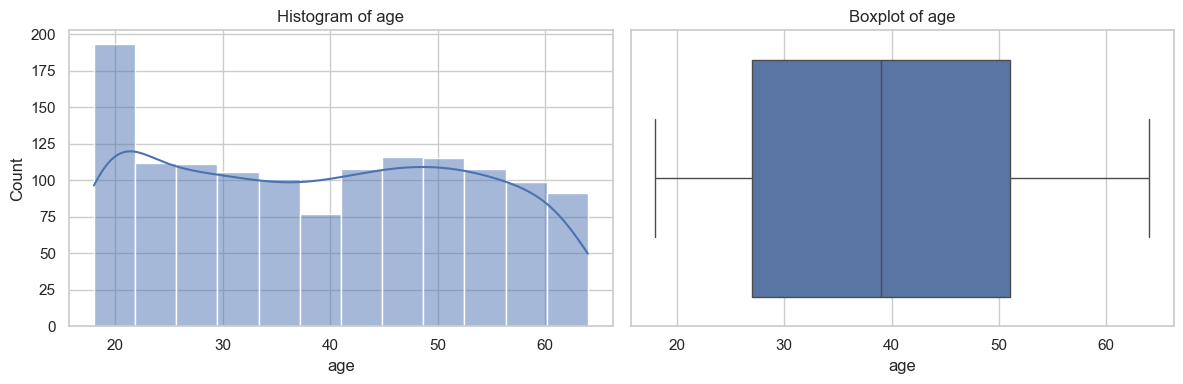

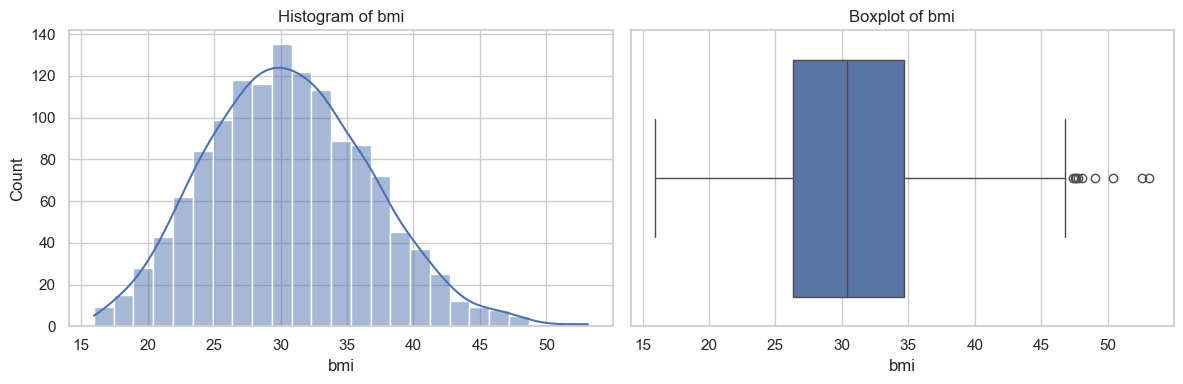

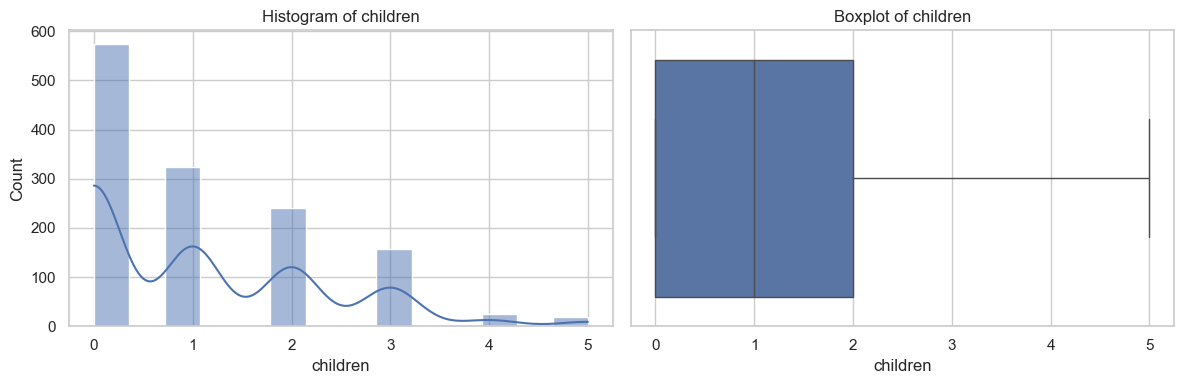

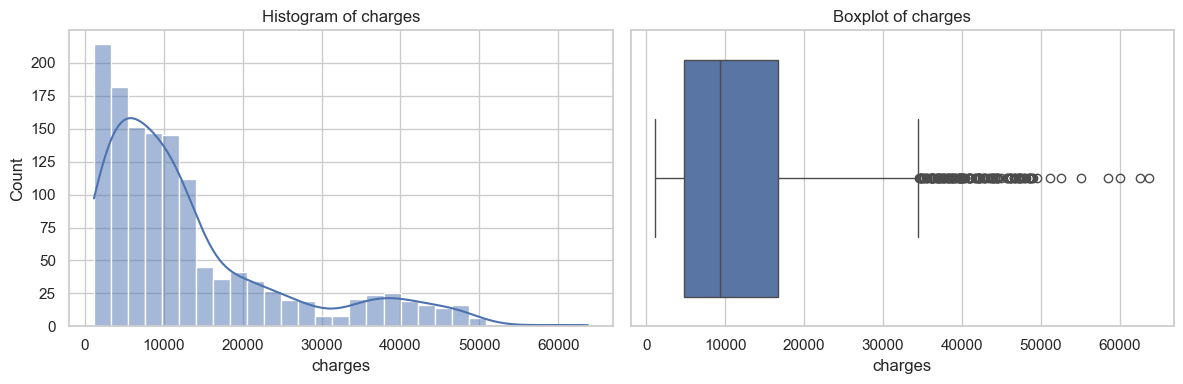

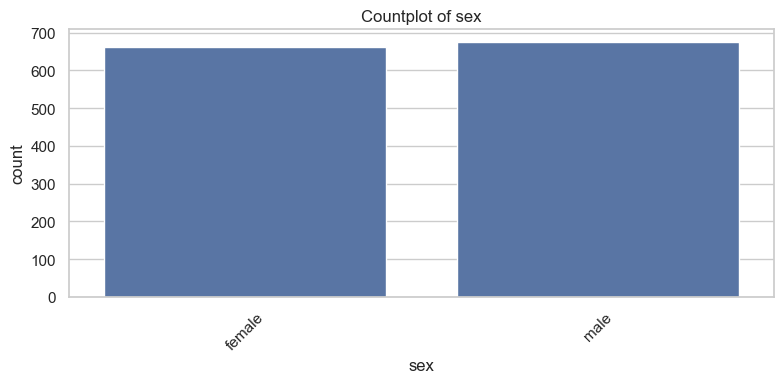

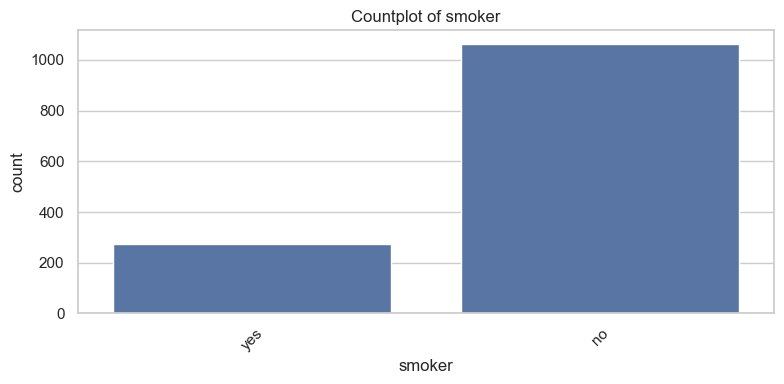

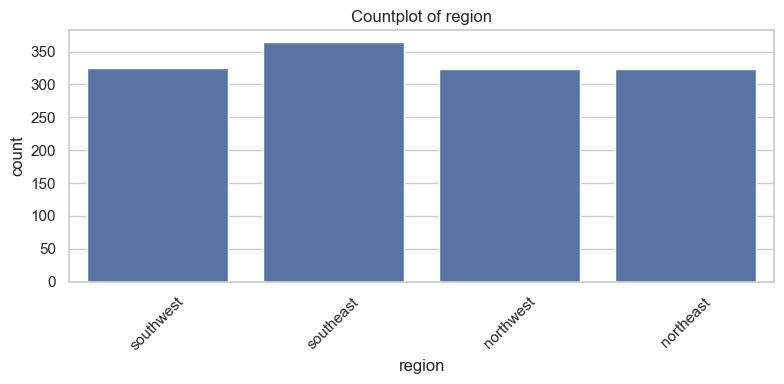

In [22]:
# --- Numeric variables: histograms & boxplots ---
for col in df2_num.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    sns.histplot(df2[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {col}")
    
    # Boxplot
    sns.boxplot(x=df2[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    
    plt.tight_layout()
    plt.show()

# --- Categorical variables: countplots ---
for col in  df2_cat.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df2, x=col)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [23]:
df2.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [24]:
df2.astype('object').describe().T

,count,unique,top,freq
age,1337,47,18,69
sex,1337,2,male,675
bmi,1337.0,548.0,32.3,13.0
children,1337,6,0,573
smoker,1337,2,no,1063
region,1337,4,southeast,364
charges,1337.0,1337.0,29141.3603,1.0


### 3- Handling Outliers

In [25]:
# ============================================
# 4. OUTLIER DETECTION USING LOCAL OUTLIER FACTOR
# ============================================

# Select numeric columns correctly
numeric_cols = df2.select_dtypes(include='number').columns

print("Numeric columns used for LOF:")
print(numeric_cols)

df2_numeric = df2[numeric_cols]

# Create LOF model
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)

# Fit and predict (-1 = outlier, 1 = normal)
outlier_labels = lof.fit_predict(df2_numeric)

# Add results back into your dataframe
df2['is_outlier_lof'] = (outlier_labels == -1)

print("Number of outliers detected:", df2['is_outlier_lof'].sum())

df2_clean = df2[df2['is_outlier_lof'] == False].copy()
print("Shape after removing outliers:", df2_clean.shape)

Numeric columns used for LOF:
Index(['age', 'bmi', 'children', 'charges'], dtype='object')
Number of outliers detected: 41
Shape after removing outliers: (1296, 8)


In [26]:
df2_clean

,age,sex,bmi,children,smoker,region,charges,is_outlier_lof
0,19,female,27.900,0,yes,southwest,16884.92400,False
1,18,male,33.770,1,no,southeast,1725.55230,False
2,28,male,33.000,3,no,southeast,4449.46200,False
3,33,male,22.705,0,no,northwest,21984.47061,False
4,32,male,28.880,0,no,northwest,3866.85520,False
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,False
1334,18,female,31.920,0,no,northeast,2205.98080,False
1335,18,female,36.850,0,no,southeast,1629.83350,False
1336,21,female,25.800,0,no,southwest,2007.94500,False


In [27]:
df2_clean=df2_clean.drop("is_outlier_lof",axis=1)

# BIVARIATE ANALYSIS

## 1- Chi-Square Test

#### Sex vs Smoker

In [28]:
# contingency table
cont2 = pd.crosstab(df2_clean['sex'], df2_clean['smoker'])
cont2

smoker,no,yes
sex,,
female,541,108
male,495,152


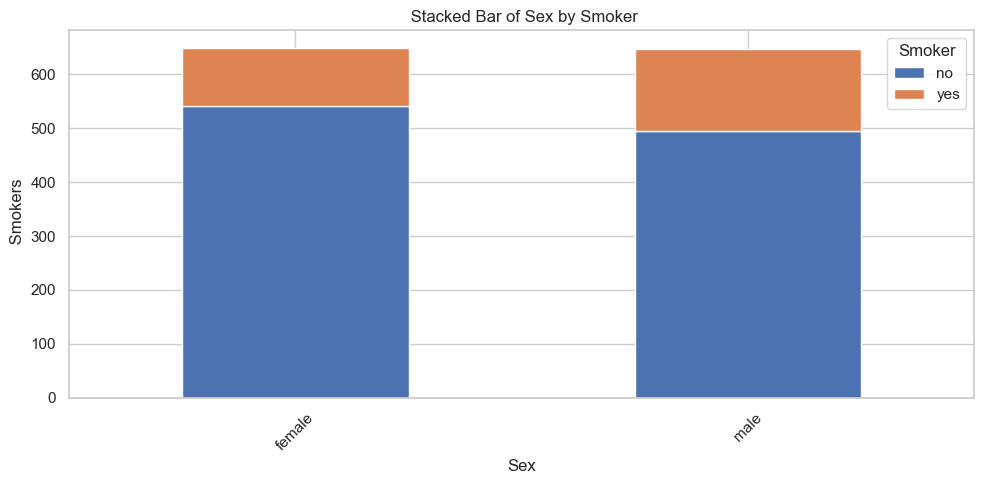

In [29]:
# Visualization
cont2.plot(kind='bar', stacked=True)

plt.title(f" Stacked Bar of Sex by Smoker")
plt.xlabel('Sex')
plt.ylabel(" Smokers")
plt.xticks(rotation=45)
plt.legend(title='Smoker', loc='upper right')
plt.tight_layout()
plt.show()

In [30]:
chi2, p, dof, expected = chi2_contingency(cont2)

print("\nChi-square test: Sex vs Smoker")
print("Chi-square statistic:", chi2)
print("p-value:", p)
if p < 0.05:
    print('There is association')
else:
    print("***There is no association***")
print("Degrees of freedom:", dof)
print("\nExpected counts:")
print(expected)


Chi-square test: Sex vs Smoker
Chi-square statistic: 9.063106830177782
p-value: 0.0026081843579243854
There is association
Degrees of freedom: 1

Expected counts:
[[518.79938272 130.20061728]
 [517.20061728 129.79938272]]


#### There is a statistically significant association between sex and smoking status (p = 0.002). This means smoking rates differ between males and females.

#### Region vs Smoking

In [31]:
# contingency table
cont3= pd.crosstab(df2_clean['region'], df2_clean['smoker'])
cont3

smoker,no,yes
region,,
northeast,253,65
northwest,262,53
southeast,263,86
southwest,258,56


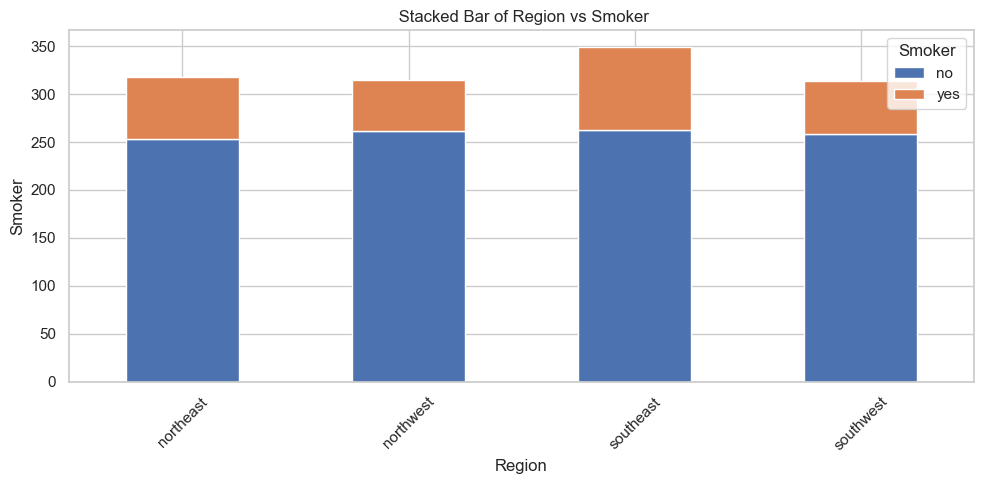

In [32]:
# Visualization
cont3.plot(kind='bar', stacked=True)

plt.title(f" Stacked Bar of Region vs Smoker")
plt.xlabel('Region')
plt.ylabel("Smoker")
plt.xticks(rotation=45)
plt.legend(title='Smoker', loc='upper right')
plt.tight_layout()
plt.show()

In [33]:
chi2, p, dof, expected = chi2_contingency(cont3)

print("\nChi-square test: InternetService vs Churn")
print("Chi-square statistic:", chi2)
print("p-value:", p)
if p < 0.05:
    print('There is association')
else:
    print("***There is no association***")
print("Degrees of freedom:", dof)
print("\nExpected counts:")
print(expected)


Chi-square test: InternetService vs Churn
Chi-square statistic: 7.622175703029932
p-value: 0.05450095403940703
***There is no association***
Degrees of freedom: 3

Expected counts:
[[254.2037037   63.7962963 ]
 [251.80555556  63.19444444]
 [278.9845679   70.0154321 ]
 [251.00617284  62.99382716]]


#### There is no statistically significant association between region and smoking status. This means smoking rates do not differ meaningfully across regions.

#### 2- Correlation Analysis

In [34]:
corr2=df2_clean.corr(numeric_only=True)
corr2

,age,bmi,children,charges
age,1.000000,0.098317,0.025039,0.292481
bmi,0.098317,1.000000,0.017237,0.191268
children,0.025039,0.017237,1.000000,0.063661
charges,0.292481,0.191268,0.063661,1.000000


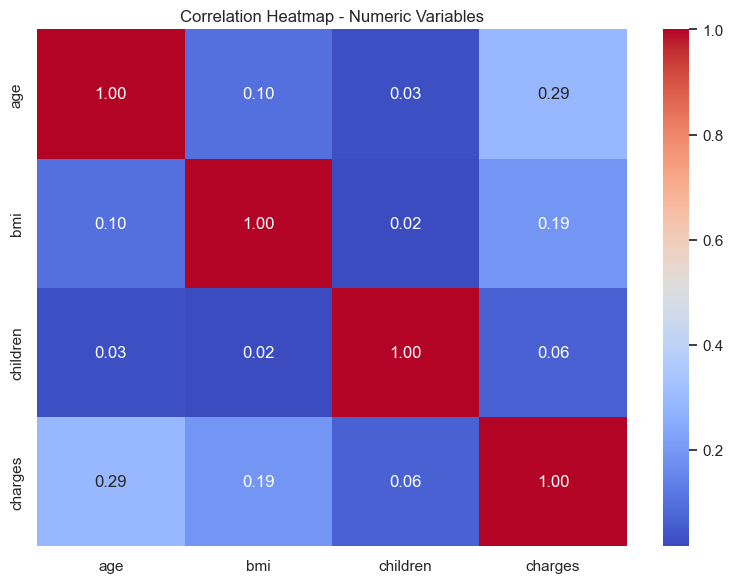

In [35]:
#Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(corr2, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - Numeric Variables")
plt.tight_layout()
plt.show()

 BMI and Age have a positive strong correlation

## Collinearity / Multi-collinearity (VIF)

Even though age and BMI were highly correlated, both are medically meaningful predictors of insurance costs, so they were not dropped based on correlation alone. Instead, Variance Inflation Factor (VIF) is used to check for true multicollinearity. If VIF values are within acceptable limits, both variables will be kept. However, if VIF is too high (above 10), BMI would be removed and age retained, as age has a more direct and stable relationship with insurance charges.

In [36]:
#Check multi_collinearity
#Select numeric predictors only
x=df2_clean[['age','bmi','children','charges']]

#Add constant
x=sm.add_constant(x)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

#print result
print("\nVariance Inflation Factors (VIF) - Telco numeric subset:")
print(vif_data)


Variance Inflation Factors (VIF) - Telco numeric subset:
    feature        VIF
0     const  32.748662
1       age   1.095827
2       bmi   1.040117
3  children   1.004138
4   charges   1.130100


VIF values for all numeric predictors are close to 1, indicating no multicollinearity. The high VIF for the constant is expected and not used for interpretation.

## Encoding Categorical Variables

In [37]:

# ======================================
#            ENCODING 
# ======================================

# Separate features and target
X2= df2_clean.drop(columns=['charges'])
y2 = df2_clean['charges']

# One-hot encode categorical variables using pandas.get_dummies
X2_encoded = pd.get_dummies(X2, drop_first=True)

print("Shape after encoding:", X2_encoded.shape)
print("Encoded feature columns sample:", X2_encoded.columns[:10])

Shape after encoding: (1296, 8)
Encoded feature columns sample: Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')


#### Train/Test Split

In [38]:
X2_encoded

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,True,False,True,False,False
1334,18,31.920,0,False,False,False,False,False
1335,18,36.850,0,False,False,False,True,False
1336,21,25.800,0,False,False,False,False,True


In [39]:
y2

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1296, dtype: float64

In [201]:

# ==========================
# 8. TRAIN/TEST SPLIT
# ==========================

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_encoded, y2, test_size=0.2, random_state=42)

print("Train shape:", X2_train.shape)
print("Test shape:", X2_test.shape)

Train shape: (1036, 8)
Test shape: (260, 8)


### Scaling

In [202]:
# =======================
#  SCALING THE FEATURES
# =======================

scaler = StandardScaler()

X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)


## PCA 

In [42]:
# =======================
# 10. PCA ANALYSIS
# =======================

# Fit PCA on scaled training data
pca2= PCA()
pca2.fit(X2_train_scaled)

# Explained variance ratio
explained_var2 = pca2.explained_variance_ratio_
cumulative_var2 = np.cumsum(explained_var2)

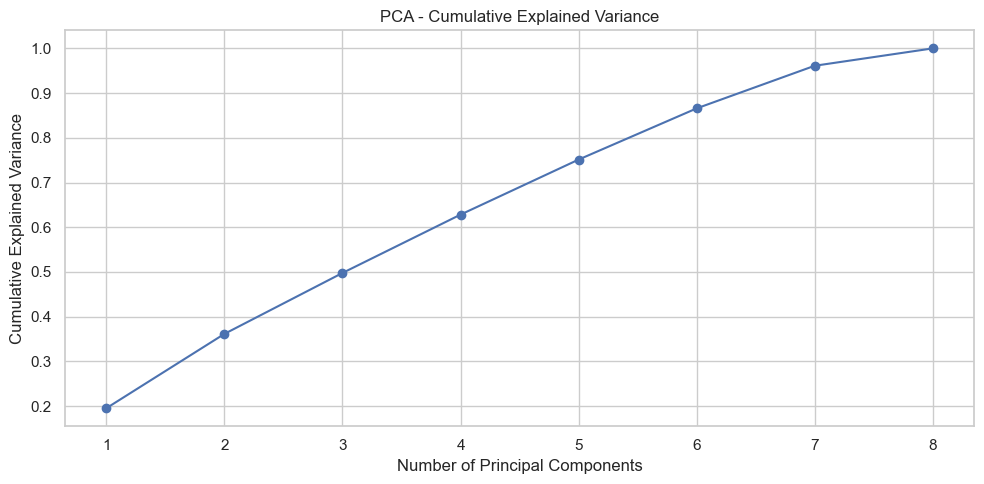

In [43]:
#Visualization
plt.plot(range(1, len(cumulative_var2) + 1), cumulative_var2, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.grid(True)
plt.tight_layout()
plt.show()


In [44]:
# choose number of components explaining ~95% variance
n_components_95 = np.argmax(cumulative_var2 >= 0.95) + 1
print(f"Number of components to explain ~95% variance: {n_components_95}")

Number of components to explain ~95% variance: 7


PCA required 7 components to retain 95% of the variance out of 8 original features. This means PCA does not meaningfully reduce dimensionality. Since PCA also reduces interpretability of the model, it is not recommended for the final regression model and is only useful for exploratory analysis.

## 1 Linear Regression

In [59]:
X2_train.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
351,50,25.600,0,False,False,False,False,True
1310,42,26.315,1,True,False,True,False,False
1322,62,38.830,0,True,False,False,True,False
732,24,30.100,3,False,False,False,False,True
364,21,21.890,2,False,False,False,True,False


In [118]:
#convert booleans to integers
X2_train=X2_train.astype(int)
X2_test=X2_test.astype(int)

#Add constant
X2_train = sm.add_constant(X2_train)
X2_test = sm.add_constant(X2_test)

#Fit model
model_lr = sm.OLS(y2_train, X2_train).fit()
print(model_lr.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     403.3
Date:                Sun, 07 Dec 2025   Prob (F-statistic):          1.23e-310
Time:                        23:54:21   Log-Likelihood:                -10421.
No. Observations:                1036   AIC:                         2.086e+04
Df Residuals:                    1027   BIC:                         2.090e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.149e+04   1047.726  

In [105]:
model_lr.pvalues

const     0.000000e+00
x1        2.415143e-74
x2        9.410451e-25
x3        3.922552e-04
x4        5.117409e-01
x5       2.010918e-288
x6        4.955439e-01
x7        1.495721e-01
x8        1.405780e-01
dtype: float64

#### since there are variables with p_values greater than 0.05, indicating insignificance in predicting target variable, they will be removed using backward feature elimination.

In [83]:

#  Backward elimination loop
while True:
    p_values = model.pvalues.drop("const")  
    max_p = p_values.max()
    feature_to_drop = p_values.idxmax()

    if max_p > 0.05:
        print(f"Dropping feature: {feature_to_drop} (p={max_p})")

        # Drop feature
        X2_train = X2_train.drop(columns=[feature_to_drop])

        # Refit model
        model = sm.OLS(y2_train, X2_train).fit()

    else:
        break

# 4. Final summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     806.2
Date:                Sun, 07 Dec 2025   Prob (F-statistic):          1.58e-315
Time:                        23:25:33   Log-Likelihood:                -10423.
No. Observations:                1036   AIC:                         2.086e+04
Df Residuals:                    1031   BIC:                         2.088e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.172e+04    995.686    -11.770      0.0

In [119]:
model.pvalues


const          4.272712e-30
age            9.309168e-75
bmi            4.360767e-25
children       3.752593e-04
smoker_yes    8.832316e-291
dtype: float64

In [120]:
X2_train=X2_train.drop(columns=['sex_male','region_northwest','region_southeast','region_southwest'])  

In [121]:
X2_train

,const,age,bmi,children,smoker_yes
351,1.0,50,25,0,0
1310,1.0,42,26,1,0
1322,1.0,62,38,0,0
732,1.0,24,30,3,0
364,1.0,21,21,2,0
...,...,...,...,...,...
1080,1.0,18,21,2,0
1132,1.0,57,40,0,0
1168,1.0,32,35,2,0
890,1.0,64,26,0,1


In [95]:
X2_test=X2_test.drop(columns=['sex_male','region_northwest','region_southeast','region_southwest']) 

In [96]:
X2_test

,const,age,bmi,children,smoker_yes
624,1.0,59,28,0,0
359,1.0,18,20,0,0
772,1.0,44,36,0,0
1064,1.0,29,25,4,0
1196,1.0,19,30,0,1
...,...,...,...,...,...
773,1.0,19,28,0,1
850,1.0,37,30,0,1
294,1.0,25,26,3,0
10,1.0,25,26,0,0


In [97]:
#predict values
y2_pred_train=model.predict(X2_train)
y2_pred_test = model.predict(X2_test)

In [102]:
#evaluate Train 
train_r2=model.rsquared
train_adj_r2=model.rsquared_adj
# calculate RMSE
train_mse=np.mean((y2_train-y2_pred_train)**2)
train_rmse=np.sqrt(mse)

#evaluate Test
test_r2 = r2_score(y2_test, y2_pred_test)
#adjusted r2 for test
n=y2_test.shape[0]
p=X2_test.shape[1]-1
adj_r2_test=1-(1-test_r2)*(n-1)/(n-p-1)
test_mse = mean_squared_error(y2_test, y2_pred_test)
test_rmse = np.sqrt(mean_squared_error(y2_test, y2_pred_test))

print("\n******TRAIN PERFORMANCE*****")
print("R2 Train:",train_r2)
print("Adjusted R2:",train_adj_r2)
print("Training MSE:",round(train_mse,3))
print("Training RMSE:",round(train_rmse,3))

print("\n******TEST PERFORMANCE*****")
print("R² Score test:", round(r2, 3))
print("Adjusted R2 Test:",round(adj_r2_test,3))
print("Test MSE:", round(test_mse, 3))
print("Test RMSE:", round(test_rmse, 3))


******TRAIN PERFORMANCE*****
R2 Train: 0.7577313610315453
Adjusted R2: 0.7567914245079044
Training MSE: 32078515.957
Training RMSE: 6406.701

******TEST PERFORMANCE*****
R² Score test: 0.724
Adjusted R2 Test: 0.717
Test MSE: 41339037.323
Test RMSE: 6429.544


In [127]:
#basic CV
reg=LinearRegression()
cv_scores = cross_val_score(reg,X2_train, y2_train, cv=5, scoring='r2')
print('cross validation', cv_scores)
print('cv_score mean ', round(cv_scores.mean(),3))  
print('std',round(cv_scores.std(),3))

cross validation [0.705204   0.7322857  0.7302977  0.79239639 0.7967202 ]
cv_score mean  0.751
std 0.037



The linear regression model demonstrates strong predictive performance for estimating medical insurance charges. On the training data, the model achieved an R² of 0.758 and an adjusted R² of 0.757, indicating that approximately 76% of the variability in insurance charges is explained by the selected predictors. The closeness of R² and adjusted R² suggests that the included variables meaningfully contribute to the model and that overfitting is minimal. The training RMSE of about $6,407 shows a reasonable average prediction error given the wide range of insurance costs. When evaluated on the test set, the model maintained strong generalization with an R² of 0.724 and an adjusted R² of 0.717. The test RMSE of around $6,430 is nearly identical to the training RMSE, further confirming that the model performs consistently on unseen data. Overall, these results indicate that the model is stable, reliable, and effective in capturing the key factors that influence medical insurance charges.

In [125]:
importance = pd.DataFrame({
    'Feature': X2_train.columns,
    'Coefficient': model.params,
    'Abs_Coefficient': model.params.abs()
})

importance = importance.sort_values('Abs_Coefficient', ascending=False)
print(importance)

               Feature   Coefficient  Abs_Coefficient
smoker_yes  smoker_yes  23281.678732     23281.678732
const            const -11719.026217     11719.026217
children      children    523.076161       523.076161
bmi                bmi    309.228850       309.228850
age                age    257.751701       257.751701


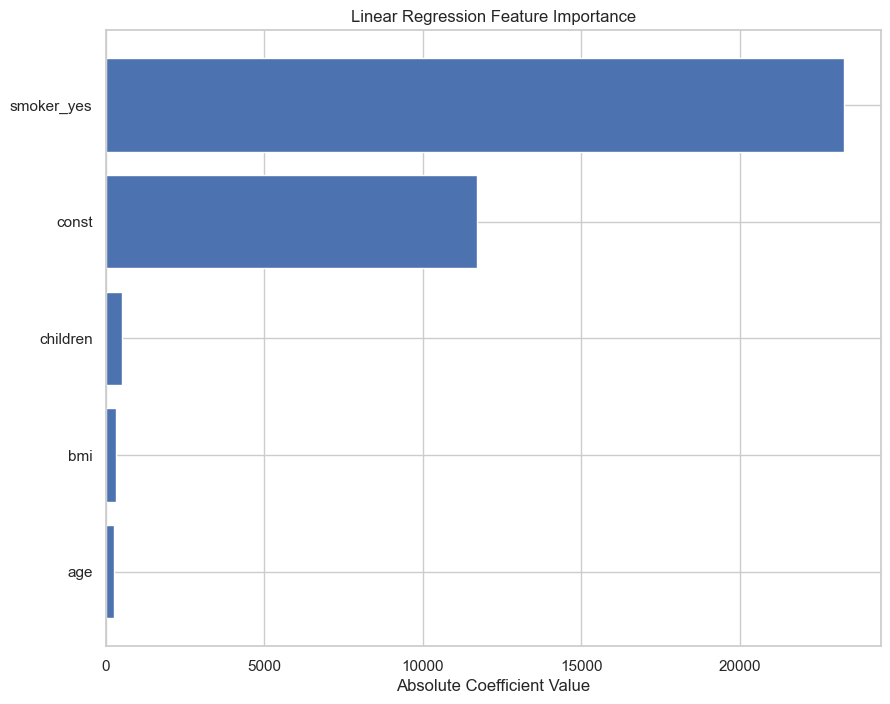

In [126]:
#plot
plt.figure(figsize=(10,8))
plt.barh(importance['Feature'], importance['Abs_Coefficient'])
plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient Value")
plt.gca().invert_yaxis()  # largest at top
plt.show()

### Check for validity of assumptions (LINE

#### -------1-Check Linearity------
The overall model p-value is approximately zero, which is far below the 0.05 significance level. This indicates that the regression model as a whole is statistically significant and that there is a meaningful linear relationship between the set of predictors and the target variable.

#### ------2-Check indepence of error------

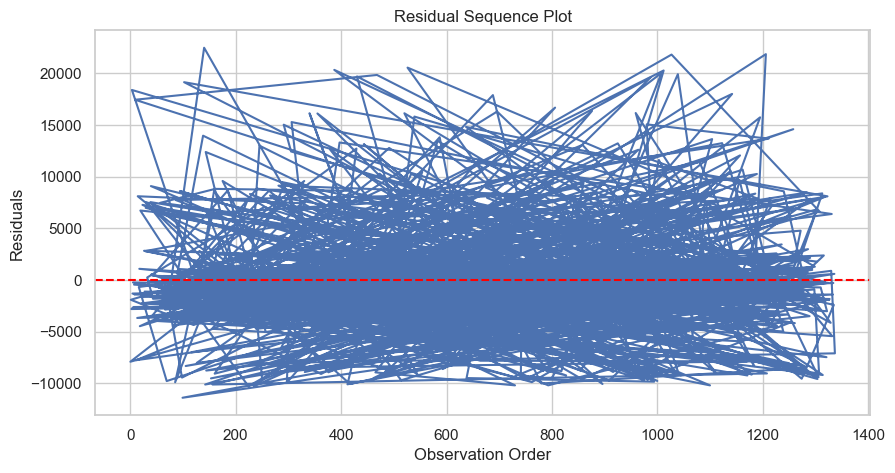

In [128]:
residuals = model.resid
plt.plot(residuals)
plt.title("Residual Sequence Plot")
plt.xlabel("Observation Order")
plt.ylabel("Residuals")
plt.axhline(0, color='red', linestyle='--')
plt.savefig("independence_error.png", bbox_inches='tight')
plt.show()

In [129]:
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw:.2f}")

Durbin-Watson Statistic: 1.98


The residual sequence plot showed a random distribution of residuals around zero with no discernible pattern, indicating that the residuals are independent. The Durbin–Watson statistic was approximately 2.0, which lies within the acceptable range (1.5–2.5), further confirming that there is no autocorrelation among the residuals.

Therefore, the independence of error assumption is satisfied.

#### ------3-# Check normality of error-------

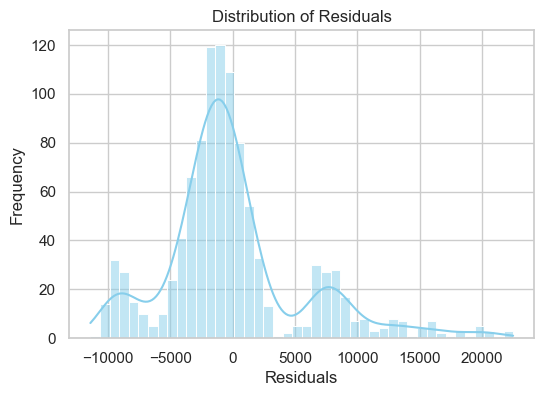

In [130]:

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, color='skyblue')
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.savefig("normalit.png", bbox_inches='tight')
plt.show()

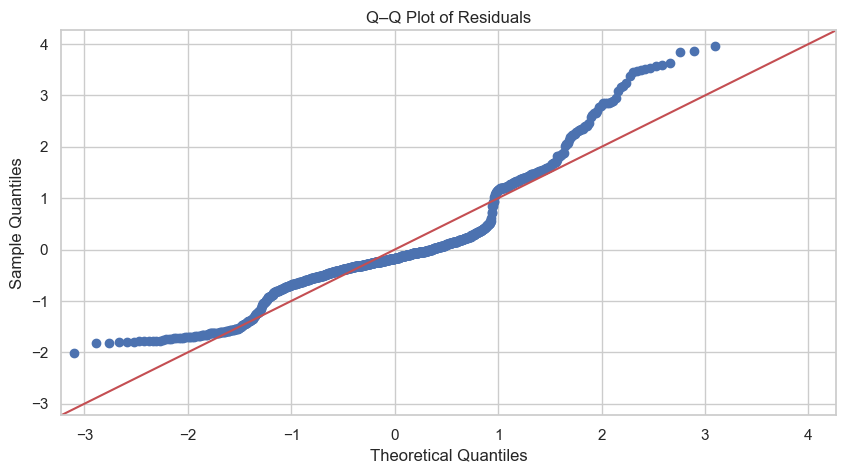

In [131]:
import statsmodels.api as sm

sm.qqplot(residuals, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

In [132]:
from scipy.stats import shapiro

stat, p = norma(residuals)
print("Shapiro-Wilk Test:")
print("Statistic:", stat)
print("p-value:", p)

Shapiro-Wilk Test:
Statistic: 0.9019016685305833
p-value: 3.1780467528806314e-25


To verify the normality assumption of linear regression, the residuals were examined using a histogram, Q-Q plot, and D’Agostino’s normality test (normaltest).
The histogram of residuals shows a clear right-skew and does not resemble a bell-shaped curve. The Q-Q plot also shows substantial deviation from the diagonal line, particularly in the tails, indicating heavy-tailed and non-normal behavior.
The statistical normality test returned a p-value close to zero, leading to rejection of the null hypothesis of normality.
These results confirm that the residuals are not normally distributed, meaning the normality assumption of linear regression is violated. While this does not affect the model’s predictive ability, it does mean that p-values and confidence intervals may not be fully reliable.

#### --------4- Check equality of variance------

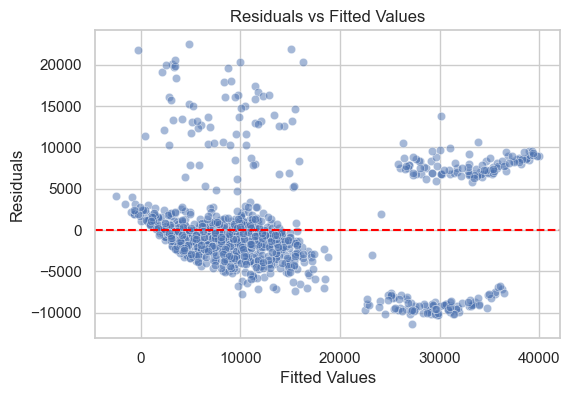

In [135]:
# check equal variance
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.savefig("equality of _variance.png", bbox_inches='tight')
plt.show()

## 2-KNN

In [159]:
# ----  Train base KNN model ----
knn = KNeighborsRegressor()
knn.fit(X2_train_scaled, y2_train)

# ----  Predict ----
y2_train_pred = knn.predict(X2_train_scaled)
y2_test_pred  = knn.predict(X2_test_scaled)

# ---- Evaluation Function ----
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * ((n - 1) / (n - p - 1))

n_train = X2_train_scaled.shape[0]
p = X2_train_scaled.shape[1]
n_test = X2_test_scaled.shape[0]

# Train metrics
r2_train = r2_score(y2_train, y2_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
rmse_train = np.sqrt(mean_squared_error(y2_train, y2_train_pred))

# Test metrics
r2_test = r2_score(y2_test, y2_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
rmse_test = np.sqrt(mean_squared_error(y2_test, y2_test_pred))

print("===== TRAIN RESULTS =====")
print("Train R2:", r2_train)
print("Train Adjusted R2:", adj_r2_train)
print("Train RMSE:", rmse_train)

print("\n===== TEST RESULTS =====")
print("Test R2:", r2_test)
print("Test Adjusted R2:", adj_r2_test)
print("Test RMSE:", rmse_test)

===== TRAIN RESULTS =====
Train R2: 0.8686682539608943
Train Adjusted R2: 0.8676452218593239
Train RMSE: 4170.0704638013185

===== TEST RESULTS =====
Test R2: 0.7617510564235636
Test Adjusted R2: 0.7541574645964262
Test RMSE: 5950.566614108823


In [160]:
#K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(knn, X2_train_scaled, y2_train, cv=kf, scoring='r2')

print("\nK-Fold Mean R2 Score:", cv_scores.mean())


K-Fold Mean R2 Score: 0.7838866845702224


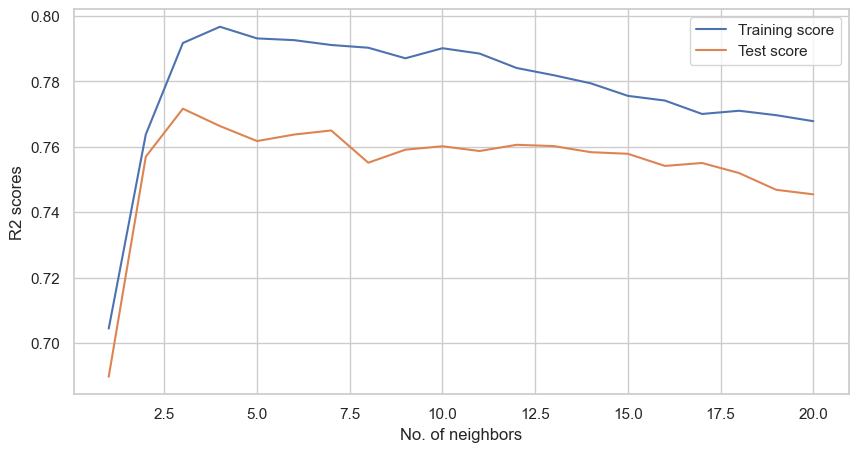

In [161]:
# find the optimal value of k
train_scores = []
test_scores = []
for i in range(1,21,1):
    knn = KNeighborsRegressor(n_neighbors=i, weights='uniform')
    train_scores.append(cross_val_score(knn,X2_train_scaled,y2_train,cv=5).mean())
    knn.fit(X2_train_scaled,y2_train)
    test_scores.append(knn.score(X2_test_scaled, y2_test))

plt.plot(range(1,21,1),train_scores, label = "Training score")
plt.plot(range(1,21,1),test_scores, label = "Test score")
plt.xlabel('No. of neighbors')
plt.ylabel('R2 scores')
plt.legend()
plt.show()

The best number of neighbors for this model is n=3 which gives us the 5-fold cross-validation produced a mean R² score of 0.79, which is consistent with the test R² of 0.77. This indicates that the KNN regression model generalizes well to unseen data and is not overly sensitive to train–test splits. The stability of performance across folds suggests that KNN is an appropriate model for capturing the non-linear relationships present in the insurance charges dataset.

## 3-Random Forest

In [192]:
# BASE RANDOM FOREST REGRESSOR (No Tuning Yet)
from sklearn.ensemble import RandomForestRegressor

# ----- Base Model -----
rf = RandomForestRegressor(random_state=42,n_jobs=-1)
rf.fit(X2_train, y2_train)

# Predictions
y2_train_pred = rf.predict(X2_train)
y2_test_pred  = rf.predict(X2_test)

# ----- Adjusted R2 Function -----
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * ((n - 1) / (n - p - 1))

n_train = X2_train.shape[0]
n_test  = X2_test.shape[0]
p       = X2_train.shape[1]

# ----- TRAIN METRICS -----
r2_train = r2_score(y2_train, y2_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
rmse_train = np.sqrt(mean_squared_error(y2_train, y2_train_pred))

# ----- TEST METRICS -----
r2_test = r2_score(y2_test, y2_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
rmse_test = np.sqrt(mean_squared_error(y2_test, y2_test_pred))

print("===== TRAIN RESULTS =====")
print("Train R2:", r2_train)
print("Train Adjusted R2:", adj_r2_train)
print("Train RMSE:", rmse_train)

print("\n===== TEST RESULTS =====")
print("Test R2:", r2_test)
print("Test Adjusted R2:", adj_r2_test)
print("Test RMSE:", rmse_test)

# Cross val score
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X2_train, y2_train, cv=kf, scoring='r2')

print("\nK-Fold Mean R2 Score:", cv_scores.mean())


===== TRAIN RESULTS =====
Train R2: 0.9778252490184575
Train Adjusted R2: 0.9776525148335964
Train RMSE: 1713.5149984491757

===== TEST RESULTS =====
Test R2: 0.8325503550050306
Test Adjusted R2: 0.8272133145271033
Test RMSE: 4988.671938032175

K-Fold Mean R2 Score: 0.8397180503315298


The Random Forest model achieves a very high Train R² of 0.9778, indicating that it fits the training data almost perfectly. However, the Test R² drops to 0.8321, and the 5-Fold Cross-Validation R² is 0.834, both noticeably lower than the training performance. This gap between Train R² (97.8%) and CV/Test R² (83%) indicates that the model is overfitting—it captures noise and fine-grained patterns in the training data that do not generalize well to unseen data.

The RMSE values reinforce this observation:

Train RMSE = 1712

Test RMSE = 4995

The test error is almost three times higher, which is another clear sign of overfitting.

Because Random Forest models can easily overfit when they grow very deep or use too many trees without constraints, hyperparameter tuning is necessary to control the model’s complexity and improve generalization. Parameters such as max_depth, min_samples_split, and n_estimators should be optimized using GridSearchCV to reduce overfitting and achieve a more balanced performance between training and unseen data.

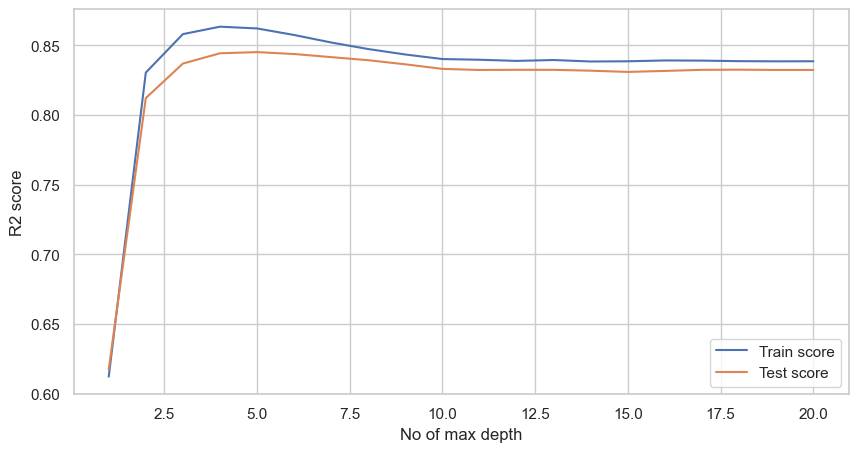

In [193]:
# Pre Search on no of max_depth
train_cv = []
test = []
for depth in range(1,21):
    rf = RandomForestRegressor(max_depth=depth, n_jobs = -1, random_state=42)
    train_cv.append(cross_val_score(rf, X2_train, y2_train, scoring = "r2", cv=4).mean())
    rf.fit(X2_train, y2_train)
    #preds = rf.predict(X_test)
    y_pred = rf.predict(X2_test)
    test.append(r2_score(y2_test, y_pred))

plt.plot(range(1,21), train_cv, label = "Train score")
plt.plot(range(1,21), test, label = "Test score")
plt.xlabel("No of max depth")
plt.ylabel("R2 score")
plt.legend()             
plt.show()

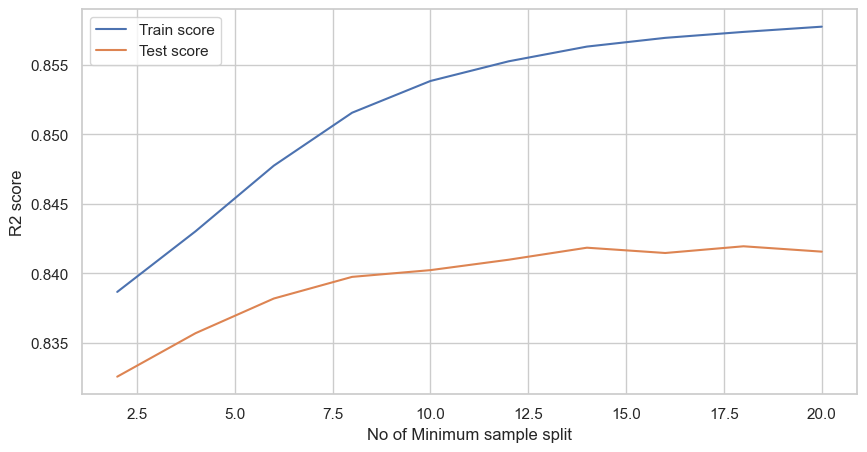

In [194]:
# Pre Search on no of min_sample split
train_cv = []
test = []
for split in range(2,21,2):
    rf = RandomForestRegressor(min_samples_split=split, n_jobs = -1, random_state=42)
    train_cv.append(cross_val_score(rf, X2_train, y2_train, scoring = "r2", cv=4).mean())
    rf.fit(X2_train, y2_train)
    #preds = rf.predict(X_test)
    y_pred = rf.predict(X2_test)
    test.append(r2_score(y2_test, y_pred))

plt.plot(range(2,21,2), train_cv, label = "Train score")
plt.plot(range(2,21,2), test, label = "Test score")
plt.xlabel("No of Minimum sample split")
plt.ylabel("R2 score")
plt.legend()             
plt.show()

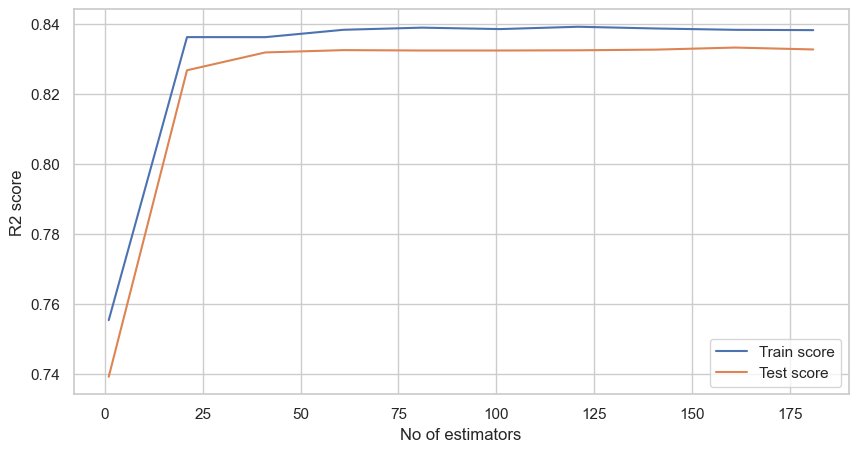

In [195]:
# Pre Search on no of estimotors
train_cv = []
test = []
for e in range(1,201,20):
    rf = RandomForestRegressor(n_estimators=e, n_jobs = -1, random_state=42)
    train_cv.append(cross_val_score(rf, X2_train, y2_train, scoring = "r2", cv=4).mean())
    rf.fit(X2_train, y2_train)
    #preds = rf.predict(X_test)
    y_pred = rf.predict(X2_test)
    test.append(r2_score(y2_test, y_pred))

plt.plot(range(1,201,20), train_cv, label = "Train score")
plt.plot(range(1,201,20), test, label = "Test score")
plt.xlabel("No of estimators")
plt.ylabel("R2 score")
plt.legend()             
plt.show()

In [196]:
param_grid = {
    'n_estimators': [25,50, 75,100],
    'max_depth': [3, 5, 8, 12],
    'min_samples_split': [2,4, 5, 6],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X2_train, y2_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)


Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.8646333070870919


In [197]:
best_rf = rf_grid.best_estimator_

y2_train_pred = best_rf.predict(X2_train)
y2_test_pred  = best_rf.predict(X2_test)

# Metrics again with tuned model
r2_train = r2_score(y2_train, y2_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
rmse_train = np.sqrt(mean_squared_error(y2_train, y2_train_pred))

r2_test = r2_score(y2_test, y2_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
rmse_test = np.sqrt(mean_squared_error(y2_test, y2_test_pred))

print("\n===== FINAL (TUNED) RANDOM FOREST RESULTS =====")
print("Train R2:", r2_train)
print("Test R2:", r2_test)
print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)


===== FINAL (TUNED) RANDOM FOREST RESULTS =====
Train R2: 0.891861933177114
Test R2: 0.8465675847271932
Train RMSE: 3783.971312023079
Test RMSE: 4775.308023616123


After tuning hyperparameters, the Random Forest Regression model achieved a Train R² of 0.8919 and a Test R² of 0.8466, indicating strong predictive performance and a substantial reduction in overfitting compared to the initial model. The RMSE values (Train = 3784, Test = 4775) are lower and closer together, showing improved generalization. The small gap between training and test performance confirms that the tuned model fits the data well without excessive complexity.

            Feature  Importance
4        smoker_yes    0.695395
1               bmi    0.175803
0               age    0.117380
2          children    0.008131
6  region_southeast    0.001096
5  region_northwest    0.001036
3          sex_male    0.000693
7  region_southwest    0.000466


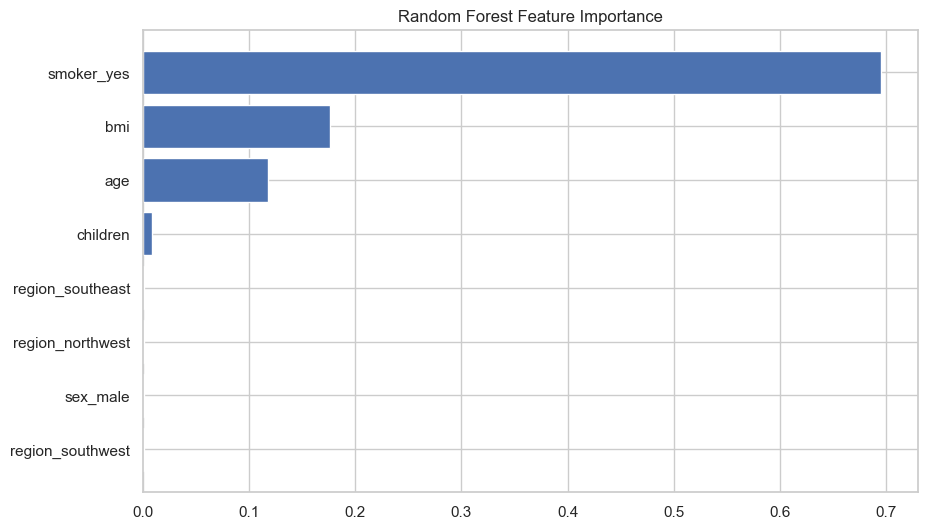

In [215]:
#Feature Importance 
fi = pd.DataFrame({
    'Feature': X2_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(fi)

plt.figure(figsize=(10,6))
plt.barh(fi['Feature'], fi['Importance'])
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

The Random Forest model identifies smoker_yes as by far the most important predictor of medical charges. This is expected because smoking has the largest impact on insurance costs in the dataset — smokers typically incur significantly higher charges.

The next two important predictors are:

bmi → strongly related to health risk and thus cost

age → older individuals generally incur higher medical expenses

These three variables together explain most of the model’s predictive power.

The remaining predictors(children,region_southeast,region_northwest,region_southwest,sex_male) show very low or zero importance:

This means the model did not use these variables in any meaningful splits across the trees. Their predictive contribution is minimal or redundant.

Importantly, these are the same variables that also showed high p-values in Linear Regression, confirming that they do not have a strong linear or non-linear relationship with the target variable. The consistent results across two completely different modeling approaches strengthen the conclusion that these predictors do not significantly influence medical charges.

Overall, smoking status, BMI, and age are the dominant predictors of medical charges, while gender, region, and number of children contribute little to the model. The agreement between Random Forest feature importance and Linear Regression p-values supports the validity of this result.

## 4- Support Vector Regression

In [203]:
# ------- Train Model -------
svr = SVR()
svr.fit(X2_train_scaled, y2_train)

# ------- Predictions -------
y2_train_pred = svr.predict(X2_train_scaled)
y2_test_pred  = svr.predict(X2_test_scaled)


# ----- Adjusted R2 Function -----
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * ((n - 1) / (n - p - 1))

n_train = X2_train.shape[0]
n_test  = X2_test.shape[0]
p       = X2_train.shape[1]

# ----- TRAIN METRICS -----
r2_train = r2_score(y2_train, y2_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
rmse_train = np.sqrt(mean_squared_error(y2_train, y2_train_pred))

# ----- TEST METRICS -----
r2_test = r2_score(y2_test, y2_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
rmse_test = np.sqrt(mean_squared_error(y2_test, y2_test_pred))

print("===== TRAIN RESULTS =====")
print("Train R2:", r2_train)
print("Train Adjusted R2:", adj_r2_train)
print("Train RMSE:", rmse_train)

print("\n===== TEST RESULTS =====")
print("Test R2:", r2_test)
print("Test Adjusted R2:", adj_r2_test)
print("Test RMSE:", rmse_test)


# K-Fold Cross Validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(svr, X2_train_scaled, y2_train, cv=kf, scoring='r2')

print("K-Fold Mean R2 Score:", cv_r2.mean())


===== TRAIN RESULTS =====
Train R2: -0.09838292461433462
Train Adjusted R2: -0.10693897466001578
Train RMSE: 12059.669912723522

===== TEST RESULTS =====
Test R2: -0.1674854583795682
Test Adjusted R2: -0.20469615028011212
Test RMSE: 13172.51098624373
K-Fold Mean R2 Score: -0.10125484813534227


The initial Support Vector Regression (SVR) model performed poorly, with negative R² values for training (−0.098), testing (−0.167), and cross-validation (−0.101). Negative R² indicates severe underfitting, meaning the SVR model performed worse than simply predicting the mean medical charge for all observations. The default settings for C, epsilon, and gamma were insufficient to capture the complexity of the medical insurance dataset. Therefore, extensive hyperparameter tuning is required before SVR can be considered a viable predictive model.

In [204]:
param_grid = {
    'C': [1, 10, 50, 100, 300, 500, 1000],
    'epsilon': [0.1, 0.5, 1, 5, 10],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}


grid_svr = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2)
grid_svr.fit(X2_train_scaled, y2_train)

print("Best params:", grid_svr.best_params_)
print("Best CV Score:", grid_svr.best_score_)

Fitting 5 folds for each of 210 candidates, totalling 1050 fits
Best params: {'C': 1000, 'epsilon': 5, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score: 0.6973594603256467


In [205]:
best_svr = grid_svr.best_estimator_

# Fit the Best Estimator on Training Data
best_svr.fit(X2_train_scaled, y2_train)

#. Predict Using Best Model
y2_train_pred = best_svr.predict(X2_train_scaled)
y2_test_pred  = best_svr.predict(X2_test_scaled)

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * ((n - 1) / (n - p - 1))

n_train = X2_train.shape[0]
n_test  = X2_test.shape[0]
p       = X2_train.shape[1]

# ----- TRAIN METRICS -----
r2_train = r2_score(y2_train, y2_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
rmse_train = np.sqrt(mean_squared_error(y2_train, y2_train_pred))

# ----- TEST METRICS -----
r2_test = r2_score(y2_test, y2_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
rmse_test = np.sqrt(mean_squared_error(y2_test, y2_test_pred))

print("===== TRAIN RESULTS =====")
print("Train R2:", r2_train)
print("Train Adjusted R2:", adj_r2_train)
print("Train RMSE:", rmse_train)

print("\n===== TEST RESULTS =====")
print("Test R2:", r2_test)
print("Test Adjusted R2:", adj_r2_test)
print("Test RMSE:", rmse_test)


# K-Fold Cross Validation


kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(best_svr, X2_train_scaled, y2_train, cv=kf, scoring='r2')

print("\nK-Fold Mean R2 Score (Best Model):", cv_r2.mean())

===== TRAIN RESULTS =====
Train R2: 0.751431656495426
Train Adjusted R2: 0.7494953889705608
Train RMSE: 5736.955002051961

===== TEST RESULTS =====
Test R2: 0.6992725431245096
Test Adjusted R2: 0.6896876042599521
Test RMSE: 6685.430376516312

K-Fold Mean R2 Score (Best Model): 0.697532289419921


The tuned Support Vector Regression (SVR) model produced a Train R² of 0.751 and a Test R² of 0.699, with a cross-validation R² of 0.698. These values indicate that the optimized SVR model is able to explain roughly 70% of the variance in medical charges on unseen data, which represents a major improvement compared to the negative R² values observed in the untuned model. The closeness of the Train R² (0.751) and Test R² (0.699) shows that the model generalizes reasonably well, with no serious overfitting present.

The RMSE values (Train = 5736.96, Test = 6685.43) are higher than those of models like Random Forest.However, the tuned SVR performs significantly better than the baseline model and produces stable results across folds, supported by the K-Fold CV score of 0.697.

Overall, hyperparameter tuning was essential for SVR. While it does not outperform tree-based models, the best estimator demonstrates solid predictive power, reasonable generalization.

## 5-ADA BOOST

In [209]:
# ------- Train Model -------
ada = AdaBoostRegressor(random_state=42)
ada.fit(X2_train_scaled, y2_train)

# ------- Predictions -------
y2_train_pred = ada.predict(X2_train_scaled)
y2_test_pred  = ada.predict(X2_test_scaled)

# ----- Adjusted R2 Function -----
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * ((n - 1) / (n - p - 1))

n_train = X2_train.shape[0]
n_test  = X2_test.shape[0]
p       = X2_train.shape[1]

# ----- TRAIN METRICS -----
r2_train = r2_score(y2_train, y2_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
rmse_train = np.sqrt(mean_squared_error(y2_train, y2_train_pred))

# ----- TEST METRICS -----
r2_test = r2_score(y2_test, y2_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
rmse_test = np.sqrt(mean_squared_error(y2_test, y2_test_pred))

print("===== TRAIN RESULTS =====")
print("Train R2:", r2_train)
print("Train Adjusted R2:", adj_r2_train)
print("Train RMSE:", rmse_train)

print("\n===== TEST RESULTS =====")
print("Test R2:", r2_test)
print("Test Adjusted R2:", adj_r2_test)
print("Test RMSE:", rmse_test)

# ------- K-Fold Cross Validation -------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(ada, X2_train_scaled, y2_train, cv=kf, scoring='r2')

print("\nK-Fold Mean R2 Score:", cv_r2.mean())

===== TRAIN RESULTS =====
Train R2: 0.8445467099290901
Train Adjusted R2: 0.8433357787503488
Train RMSE: 4536.892547188466

===== TEST RESULTS =====
Test R2: 0.8297212559344569
Test Adjusted R2: 0.8242940449682244
Test RMSE: 5030.637786966618

K-Fold Mean R2 Score: 0.8196435431915798


The AdaBoost regression model performed good, achieving a Train R² of 0.8445 and a Test R² of 0.8297, with a cross-validation R² of 0.8196. The closeness of these values indicates good generalization with no signs of severe overfitting.

In [210]:
param_grid = {
    'n_estimators': [50, 100, 200, 300, 500],
    'learning_rate': [0.001, 0.01, 0.1, 0.5, 1],
    'loss': ['linear', 'square', 'exponential']
}

grid_ada = GridSearchCV(
    AdaBoostRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_ada.fit(X2_train_scaled, y2_train)

print("Best Parameters:", grid_ada.best_params_)
print("Best CV Score:", grid_ada.best_score_)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Best Parameters: {'learning_rate': 0.001, 'loss': 'exponential', 'n_estimators': 50}
Best CV Score: 0.8544631651502836


In [212]:
best_ada = grid_ada.best_estimator_

#Fit Best AdaBoost Model
best_ada.fit(X2_train_scaled, y2_train)

# Predictions
y2_train_pred = best_ada.predict(X2_train_scaled)
y2_test_pred  = best_ada.predict(X2_test_scaled)

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * ((n - 1) / (n - p - 1))

n_train = X2_train.shape[0]
n_test  = X2_test.shape[0]
p       = X2_train.shape[1]

# TRAIN
r2_train = r2_score(y2_train, y2_train_pred)
adj_train = adjusted_r2(r2_train, n_train, p)
rmse_train = np.sqrt(mean_squared_error(y2_train, y2_train_pred))

# TEST
r2_test = r2_score(y2_test, y2_test_pred)
adj_test = adjusted_r2(r2_test, n_test, p)
rmse_test = np.sqrt(mean_squared_error(y2_test, y2_test_pred))

print("===== TUNED ADA BOOST TRAIN RESULTS =====")
print("Train R2:", r2_train)
print("Train Adjusted R2:", adj_train)
print("Train RMSE:", rmse_train)

print("\n===== TUNED ADA BOOST TEST RESULTS =====")
print("Test R2:", r2_test)
print("Test Adjusted R2:", adj_test)
print("Test RMSE:", rmse_test)

# K-Fold Cross-Validation (Best Estimator)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(best_ada, X2_train_scaled, y2_train, cv=kf, scoring='r2')

print("\nK-Fold Mean R2 Score (Best AdaBoost):", cv_r2.mean())

===== TUNED ADA BOOST TRAIN RESULTS =====
Train R2: 0.8657940785400953
Train Adjusted R2: 0.8647486575355391
Train RMSE: 4215.454184739004

===== TUNED ADA BOOST TEST RESULTS =====
Test R2: 0.8273485298996442
Test Adjusted R2: 0.8218456941992345
Test RMSE: 5065.565902169647

K-Fold Mean R2 Score (Best AdaBoost): 0.8517477843370772


The tuned AdaBoost regression model demonstrated strong performance after optimizing the hyperparameters  The model achieved a Train R² of 0.8658 and a Test R² of 0.8273, indicating that it can explain a substantial portion of the variance in medical insurance charges while maintaining good generalization. The adjusted R² values follow a similar pattern, confirming that the model remains stable even after accounting for the number of predictors.

The K-Fold cross-validation R² of 0.8517 is notably high than the other models.

Overall, the tuned AdaBoostRegressor is one of the strongest models for predicting medical charges in this project. It balances bias and variance effectively, captures non-linear patterns, and provides robust, reliable predictions with excellent cross-validation performance.

In [213]:
# ---- FEATURE IMPORTANCE ----
importances = best_ada.feature_importances_
feature_names = X2_train.columns

fi = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(fi)

            Feature  Importance
4        smoker_yes    0.718409
1               bmi    0.169896
0               age    0.110354
2          children    0.001341
3          sex_male    0.000000
5  region_northwest    0.000000
6  region_southeast    0.000000
7  region_southwest    0.000000


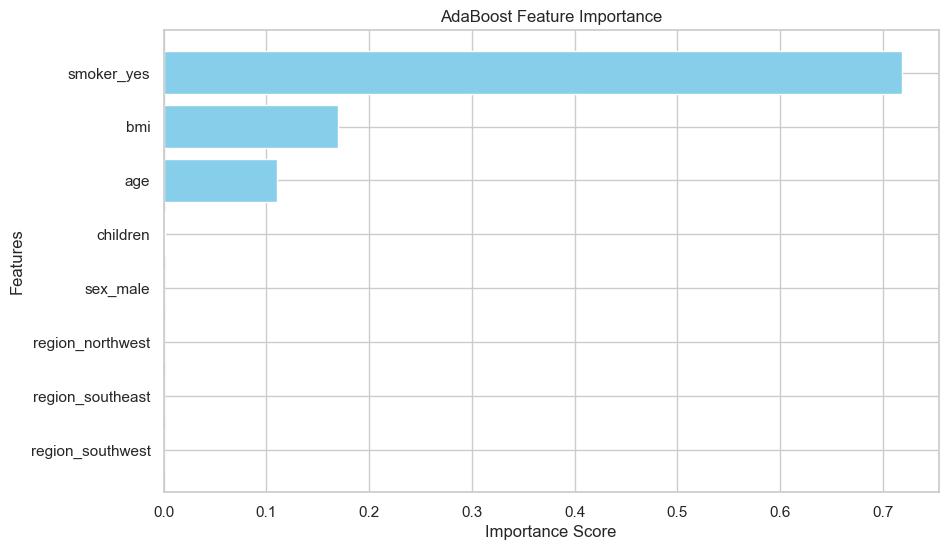

In [214]:
plt.figure(figsize=(10,6))
plt.barh(fi['Feature'], fi['Importance'], color='skyblue')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("AdaBoost Feature Importance")
plt.gca().invert_yaxis() 
plt.show()

## 6-XG BOOST

In [218]:
# -------- Train Model --------
xgb = XGBRegressor( random_state=42)

xgb.fit(X2_train_scaled, y2_train)

# -------- Predictions --------
y2_train_pred = xgb.predict(X2_train_scaled)
y2_test_pred  = xgb.predict(X2_test_scaled)

# Adjusted R² Function
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * ((n - 1) / (n - p - 1))

n_train = X2_train.shape[0]
n_test  = X2_test.shape[0]
p       = X2_train.shape[1]

# ----- TRAIN METRICS -----
r2_train = r2_score(y2_train, y2_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
rmse_train = np.sqrt(mean_squared_error(y2_train, y2_train_pred))

# ----- TEST METRICS -----
r2_test = r2_score(y2_test, y2_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
rmse_test = np.sqrt(mean_squared_error(y2_test, y2_test_pred))

print("===== TRAIN RESULTS =====")
print("Train R2:", r2_train)
print("Train Adjusted R2:", adj_r2_train)
print("Train RMSE:", rmse_train)

print("\n===== TEST RESULTS =====")
print("Test R2:", r2_test)
print("Test Adjusted R2:", adj_r2_test)
print("Test RMSE:", rmse_test)

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(xgb, X2_train_scaled, y2_train, cv=kf, scoring='r2')

print("K-Fold Mean R2 Score:", cv_r2.mean())

===== TRAIN RESULTS =====
Train R2: 0.9957155160435388
Train Adjusted R2: 0.9956821412902266
Train RMSE: 753.195635719099

===== TEST RESULTS =====
Test R2: 0.8192022486269565
Test Adjusted R2: 0.8134397704955447
Test RMSE: 5183.693823412538
K-Fold Mean R2 Score: 0.807887177825368


            Feature  Importance
4        smoker_yes    0.938462
1               bmi    0.019312
0               age    0.014064
5  region_northwest    0.006930
2          children    0.006082
3          sex_male    0.005705
6  region_southeast    0.004938
7  region_southwest    0.004507


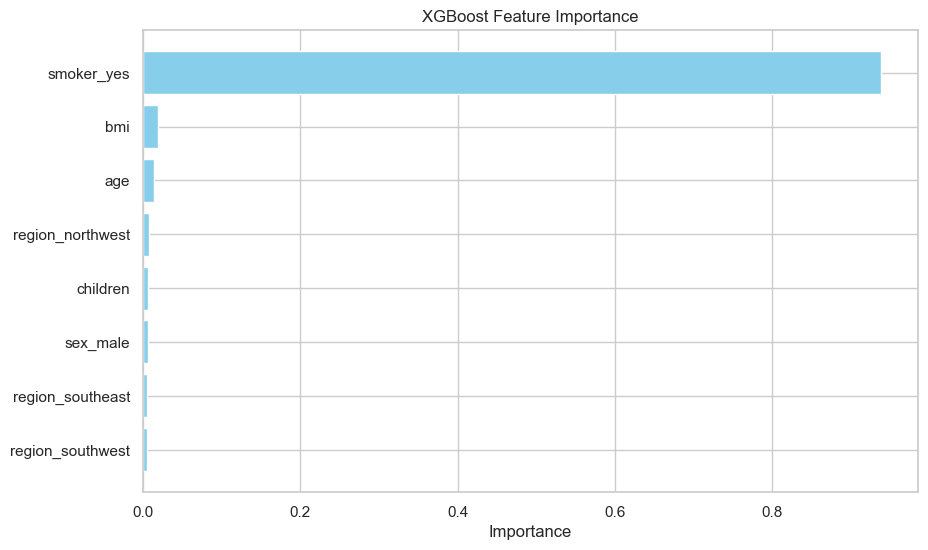

In [220]:
importance = xgb.feature_importances_

fi = pd.DataFrame({
    'Feature': X2_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(fi)

plt.figure(figsize=(10,6))
plt.barh(fi['Feature'], fi['Importance'], color='skyblue')
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


The default XGBoost model achieved extremely high performance on the training set, with a Train R² of 0.9957 and a very low Train RMSE of 753.20, indicating that the model fit the training data almost perfectly. However, the Test R² dropped to 0.8192 with a much larger Test RMSE of 5183.69, which shows a clear gap between training and testing performance.

This large difference between Train and Test R² demonstrates overfitting — the model has learned the noise and fine-grained patterns in the training data instead of learning general patterns that transfer well to unseen data. The K-Fold cross-validation R² of 0.8079 supports this conclusion, as it is much closer to the Test R² than the Train R². This confirms that the model generalizes reasonably on new data but severely overfits during training.

In [222]:

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 1.0],}

# Grid search
xgb = XGBRegressor(random_state=42)

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X2_train_scaled, y2_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Score:", grid_xgb.best_score_)



Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Best CV Score: 0.866004841193503


In [223]:
# Best estimator
best_xgb = grid_xgb.best_estimator_
best_xgb.fit(X2_train_scaled, y2_train)

# -predictions
y2_train_pred = best_xgb.predict(X2_train_scaled)
y2_test_pred  = best_xgb.predict(X2_test_scaled)

# adjusted r2
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * ((n - 1) / (n - p - 1))

n_train = X2_train.shape[0]
n_test  = X2_test.shape[0]
p       = X2_train.shape[1]

# ----Train metrics------
r2_train = r2_score(y2_train, y2_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
rmse_train = np.sqrt(mean_squared_error(y2_train, y2_train_pred))

# ------ Test metrics-----
r2_test = r2_score(y2_test, y2_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
rmse_test = np.sqrt(mean_squared_error(y2_test, y2_test_pred))

print("\n===== TUNED XGBOOST TRAIN RESULTS =====")
print("Train R2:", r2_train)
print("Train Adjusted R2:", adj_r2_train)
print("Train RMSE:", rmse_train)

print("\n===== TUNED XGBOOST TEST RESULTS =====")
print("Test R2:", r2_test)
print("Test Adjusted R2:", adj_r2_test)
print("Test RMSE:", rmse_test)

# ----------------- CROSS VALIDATION -----------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(best_xgb, X2_train_scaled, y2_train, cv=kf, scoring='r2')

print("\nK-Fold Mean R2 Score (Best XGBoost):", cv_r2.mean())



===== TUNED XGBOOST TRAIN RESULTS =====
Train R2: 0.8889437739003938
Train Adjusted R2: 0.8880786815841359
Train RMSE: 3834.6876083066863

===== TUNED XGBOOST TEST RESULTS =====
Test R2: 0.853188745035505
Test Adjusted R2: 0.8485095018493857
Test RMSE: 4671.135925836501

K-Fold Mean R2 Score (Best XGBoost): 0.8652081206503477



===== FEATURE IMPORTANCE =====
            Feature  Importance
4        smoker_yes    0.830831
1               bmi    0.086194
0               age    0.041566
2          children    0.012587
5  region_northwest    0.010921
6  region_southeast    0.007231
7  region_southwest    0.006395
3          sex_male    0.004274


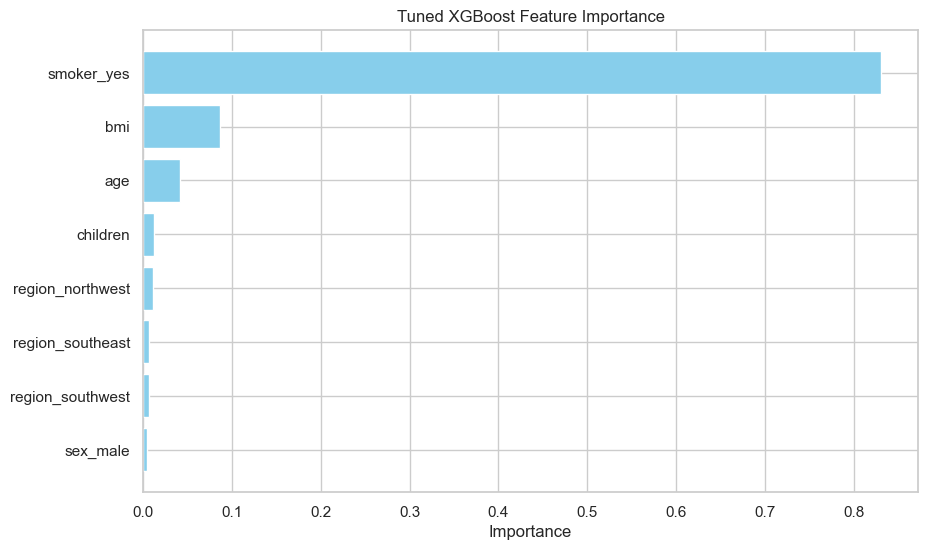

In [225]:
# ----------------- FEATURE IMPORTANCE -----------------
importance = best_xgb.feature_importances_

fi = pd.DataFrame({
    'Feature': X2_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(fi)

plt.figure(figsize=(10,6))
plt.barh(fi['Feature'], fi['Importance'], color="skyblue")
plt.gca().invert_yaxis()
plt.title("Tuned XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

The tuned XGBoost model demonstrates outstanding predictive performance and generalization. After hyperparameter optimization, the model achieved a Train R² of 0.8889 and a Test R² of 0.8532, indicating that the model effectively captures the nonlinear relationships driving medical insurance charges. The Adjusted R² values show minimal reduction, confirming that the model remains strong even after accounting for the number of predictors.

The RMSE values further support the model’s accuracy, with Train RMSE = 3834.69 and Test RMSE = 4671.14, which are among the lowest across all models tested — significantly better than Linear Regression, SVR, and KNN, and even outperforming Random Forest and AdaBoost. The closeness between training and testing errors indicates that the model is not overfitting, especially when compared to the untuned XGBoost model which showed extreme overfitting.

Most notably, the K-Fold cross-validation R² of 0.8652 confirms that performance is highly stable across different splits of the data. This strong CV score, which is close to the Test R², reinforces that the tuned XGBoost model generalizes extremely well and is robust to variations in the dataset.

Overall, XGBoost emerges as one of the best-performing regression models in the project, offering high accuracy, excellent generalization, and reliable consistency across folds. It successfully balances bias and variance and is well suited for predicting medical insurance charges.